#### Note: Please open in Jupyter's Notebook!

# Health Insurance personal attributes and incurred medical insurance costs

# SECTION 1: Read in and analyze Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import scipy, scipy.stats
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


import statsmodels.formula.api as sm
import statsmodels.formula.api as smf
import statsmodels.api as sm 
import statsmodels.formula.api as smf 
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder #for feature engineering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import (
    ConfusionMatrixDisplay

)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error # for␣evaluating ml models
from sklearn.preprocessing import OneHotEncoder

# For visual inspection of the regression models
from statsmodels.graphics.regressionplots import plot_regress_exog, plot_fit, plot_leverage_resid2, influence_plot
from scipy.stats import shapiro, levene, mannwhitneyu
from scipy.stats import chi2_contingency

# Output in a way that is not always requiring scrolling
#from IPython.display import Javascript
#display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 500000})'''))

# ---- Auto-save plots to images/ folder ----
import os
os.makedirs('images', exist_ok=True)

def save_fig(name):
    """Save current matplotlib figure to images/<name>.png"""
    plt.gcf().savefig(f'images/{name}.png', dpi=150, bbox_inches='tight')

def save_grid(g, name):
    """Save a seaborn FacetGrid / PairGrid to images/<name>.png"""
    g.savefig(f'images/{name}.png', dpi=150, bbox_inches='tight')


In [2]:
# Load the dataset
df = pd.read_csv('insurance.csv')
df.info()
print(df.describe())
print(df.nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max     

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
# Basic Checking of Data in Dataset:
# no. of duplicates
duplicates = len(df[df.duplicated()])

# no of missing values
missing_values = df.isnull().sum().sum()

print('Number of Duplicate Entries: %d'%(duplicates))
print('Number of Missing Values: %d'%(missing_values))
print('Number of Features: %d'%(df.shape[1]))
print('Number of Observations: %d'%(df.shape[0]))

Number of Duplicate Entries: 1
Number of Missing Values: 0
Number of Features: 7
Number of Observations: 1338


In [6]:

print("Object type columns: ",list(df.select_dtypes(include='object')))
# modified the code to increase clairty of the lists being returned
print("Number type columns: ", list(df.select_dtypes(include='number')))

Object type columns:  ['sex', 'smoker', 'region']
Number type columns:  ['age', 'bmi', 'children', 'charges']


The dataset does not have any missing values, which is great for our analysis. Each column has complete data.

Input variables:
1. age: Age of the individual.
2. sex: Gender (male/female).
3. BMI: Body Mass Index.
4. children: Number of children/dependents.
5. smoker: Smoking status (yes/no).
6. region: Geographical region.

Response variables:
1. charges: Individual medical costs billed by health insurance.

In [7]:
# droping duplicate values
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [8]:
# rows, columns
print(df.shape)
#rows*columns
print(df.size)

(1337, 7)
9359


In [9]:
# define a pie plot function
def pie_plot(column, ax):
    ax.pie(df[column].value_counts(), autopct="%0.2f%%",
           labels=df[column].value_counts().index,
           colors=['#1f77b4', '#3498db', '#74b9ff'])  # Different shades of blue
    ax.set(title=f"Pie Chart of {column}")

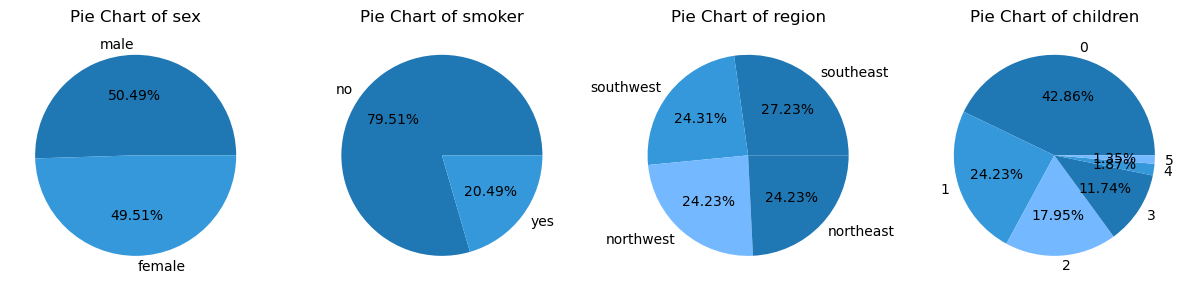

In [10]:
# categorical columns and plot the pie chart
columns = ["sex", "smoker", "region",'children']
fig, axes = plt.subplots(1, len(columns), figsize=(12, 4))

for i, column in enumerate(columns):
    pie_plot(column, axes[i])

plt.tight_layout()
save_fig('01_pie-charts-categoricals')
plt.show()

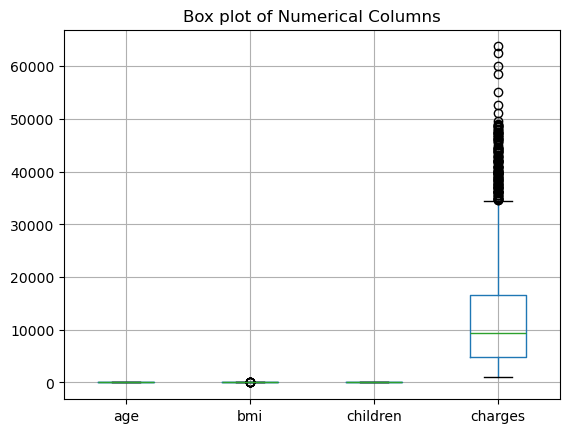

In [11]:
# Visualize box plots for numerical columns
df.boxplot(column=['age', 'bmi', 'children', 'charges'])
plt.title('Box plot of Numerical Columns')
save_fig('02_boxplot-all-numerical')
plt.show()

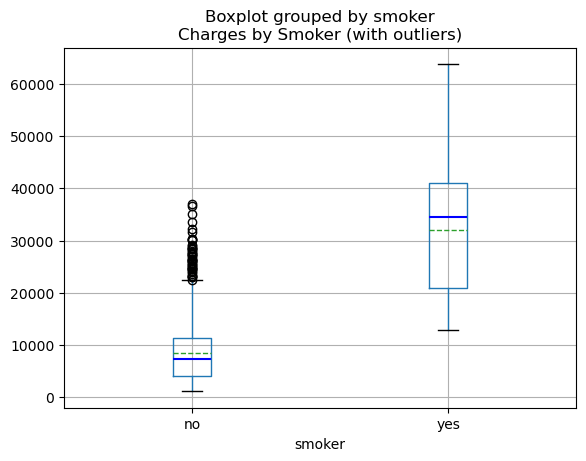

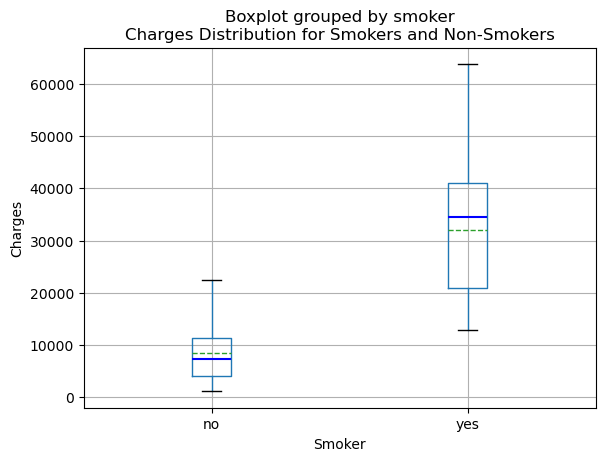

In [12]:
# added mean to better understand data distribution
df.boxplot(column='charges', by='smoker', showmeans = True, meanline = True, medianprops = dict(color = "blue", linewidth = 1.5))
plt.title('Charges by Smoker (with outliers)')
save_fig('03_boxplot-charges-by-smoker')
plt.show()
#do we want to show outliers? if not
df.boxplot(column='charges', by='smoker', showfliers = False, showmeans = True, meanline = True, medianprops = dict(color = "blue", linewidth = 1.5))
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.title('Charges Distribution for Smokers and Non-Smokers')
save_fig('04_boxplot-charges-by-smoker-nofliers')
plt.show()


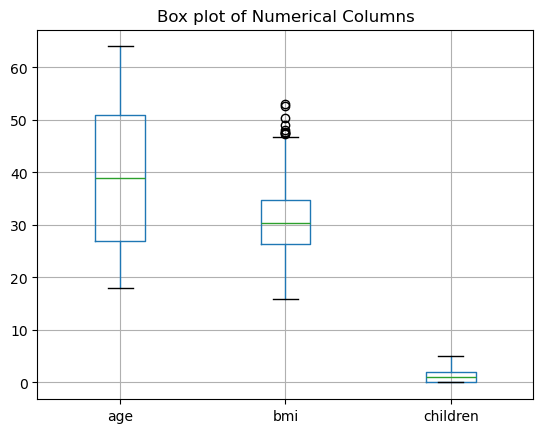

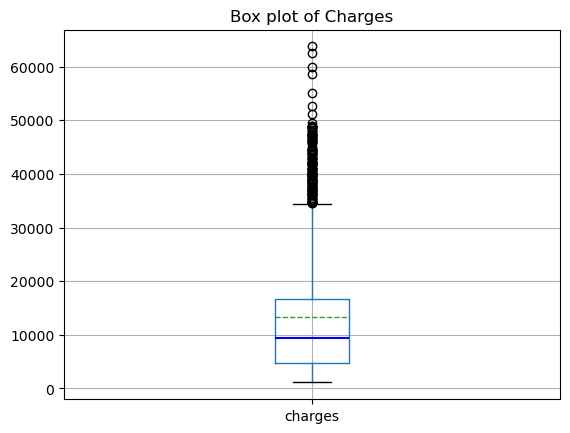

In [13]:
# Visualize box plots for numerical columns, separating age, bmi and children from charges
df.boxplot(column=['age', 'bmi', 'children'])
plt.title('Box plot of Numerical Columns')
save_fig('05_boxplot-age-bmi-children')
plt.show()

df.boxplot(column=['charges'], showmeans = True, meanline = True, medianprops = dict(color = "blue", linewidth = 1.5))
plt.title('Box plot of Charges')
save_fig('06_boxplot-charges-only')
plt.show()

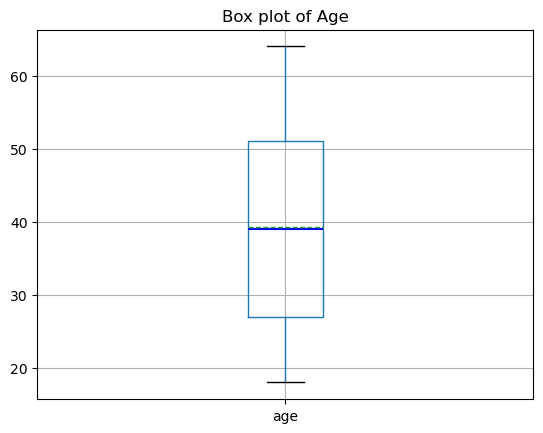

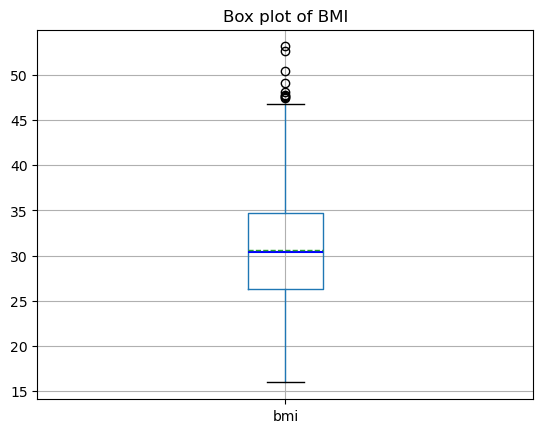

In [14]:
df.boxplot(column=['age'],showmeans = True, meanline = True, medianprops = dict(color = "blue", linewidth = 1.5))
plt.title('Box plot of Age')
save_fig('07_boxplot-age')
plt.show()

df.boxplot(column=['bmi'], showmeans = True, meanline = True, medianprops = dict(color = "blue", linewidth = 1.5))
plt.title('Box plot of BMI')
save_fig('08_boxplot-bmi')
plt.show()

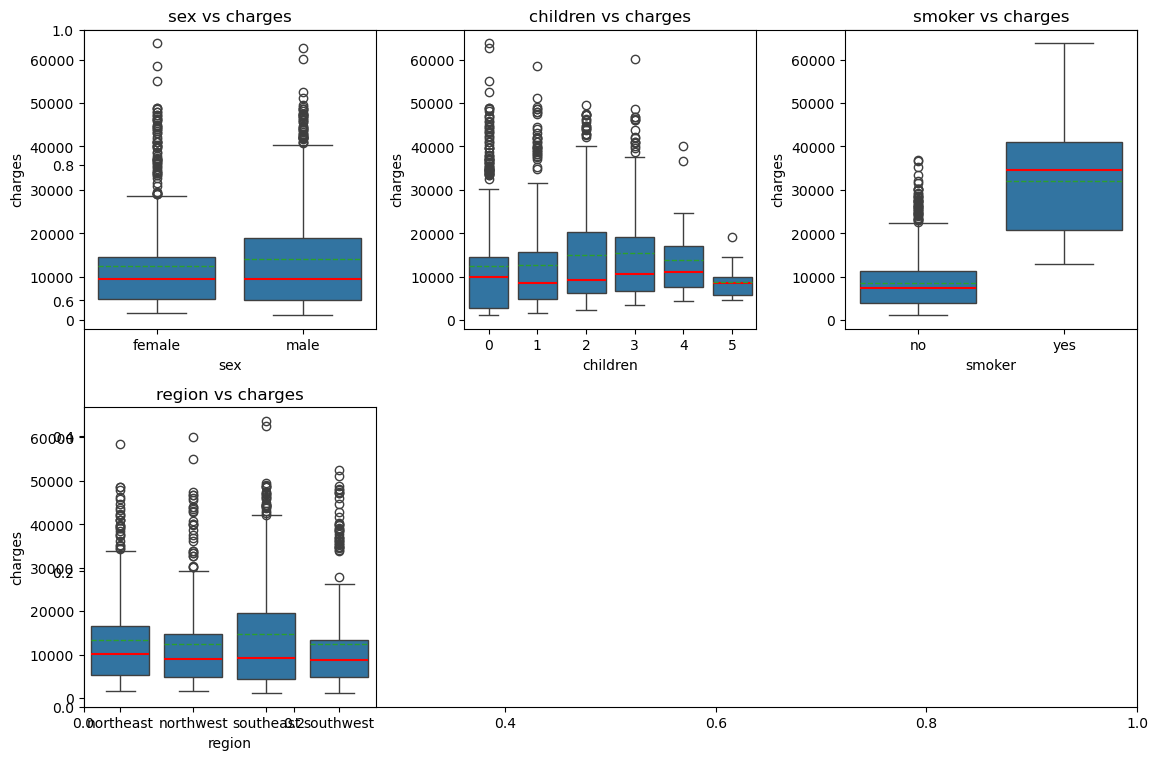

In [15]:
# box plot of 'charges' & other variables
fig, ax = plt.subplots(figsize=(12, 8))
for i, col in enumerate([col for col in df.columns if df[col].nunique() <= 6], 1):
    plt.subplot(2, 3, i)

    ax = sns.boxplot(data=df, x=df[col].astype('category'), y='charges', showmeans = True, meanline = True, medianprops = dict(color = "red", linewidth = 1.5))
    plt.title(f'{col} vs charges')

plt.tight_layout()
save_fig('09_boxplot-charges-by-categoricals')
plt.show()

In [16]:
# total charges by region
df.region.value_counts().plot(kind='bar', color=sns.color_palette("ch:s=.25,rot=-.25"))
# Add labels and title
plt.xlabel('Region')

plt.ylabel('Total Charges')
plt.title('Total Charges by Region')

# Rotate x-axis labels for better visibility (optional)
plt.xticks(rotation=45)
plt.xticks(rotation=0)
save_fig('10_barplot-charges-by-region')


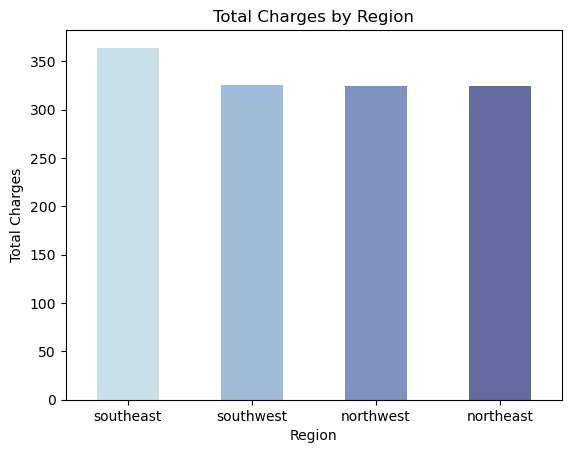

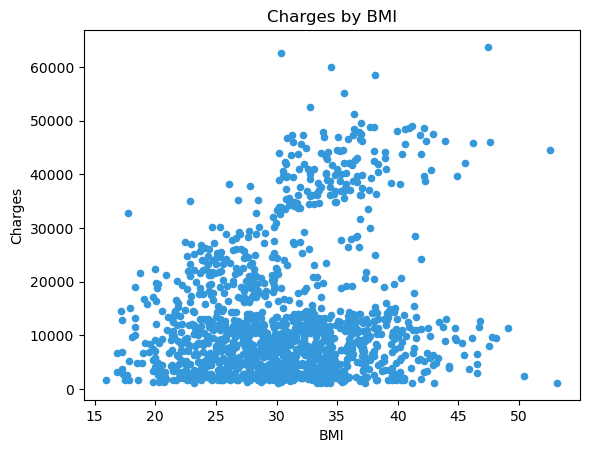

In [17]:
# relationship between BMI and charges
df.plot(kind='scatter', x='bmi', y='charges', color='#3498db')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.title('Charges by BMI')
save_fig('11_scatter-charges-by-bmi')
plt.show()

In [18]:
df.groupby(['region'])\
    ['charges'].agg(['mean','median', 'min', 'max']).round(2)

,mean,median,min,max
region,,,,
northeast,13406.38,10057.65,1694.80,58571.07
northwest,12450.84,8976.98,1621.34,60021.40
southeast,14735.41,9294.13,1121.87,63770.43
southwest,12346.94,8798.59,1241.56,52590.83


BMI can be categorized into several categories as determined by the Centers for Disease Control and Prevention (CDC):

Underweight: less than or equal to 18.4 kg/m2

Normal weight: 18.5 - 24.9 kg/m2

Overweight: 25.0 - 29.9 kg/m2

Obese: 30.0 - 60.0 kg/m2

In [19]:
# charges by BMI group
bins = [0,18.5,25,30,60]
bin_labels = ['underweight','normal','overweight', 'obese']

#creating a new attribute `bmi_group`:
df['bmi_group'] = pd.cut(df.bmi, bins, right=False, labels = bin_labels)

df.bmi_group.value_counts().sort_index()
sns.scatterplot(x="bmi_group", y="charges", hue="bmi_group", data=df)
plt.xlabel('BMI Group')
plt.ylabel('Charges')
plt.title('Charges by BMI')
save_fig('12_scatter-charges-by-bmigroup')


In [20]:
pd.cut(df['bmi'], [0,18.5,25,30,60], labels=["underweight", "normal", "overweight", "obese"]).value_counts()

bmi
obese          704
overweight     386
normal         226
underweight     21
Name: count, dtype: int64

In [21]:
# Precentage of categorized BMI
def percetage_data(df=None, column=None,sort=True):
    value_counts = df[column].value_counts(sort=sort)
    df_percentage = pd.DataFrame({'count': value_counts,
                                  'percentage': round(value_counts *100 / len(df),2)
                                 })

    return df_percentage

percetage_data(df,'bmi_group')

,count,percentage
bmi_group,,
obese,706,52.80
overweight,386,28.87
normal,225,16.83
underweight,20,1.50


In [22]:
df.groupby(['bmi_group'])\
    ['charges'].agg(['mean','median', 'min', 'max']).round(2)

C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\2137049437.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['bmi_group'])\


,mean,median,min,max
bmi_group,,,,
underweight,8852.20,6759.26,1621.34,32734.19
normal,10409.34,8603.82,1121.87,35069.37
overweight,10987.51,8659.38,1252.41,38245.59
obese,15572.04,10003.65,1131.51,63770.43


Upon analysis, it becomes evident that insurance policyholders who are categorized as "Obese" tend to incur higher charges, whereas those categorized as "Underweight" generally exhibit lower median charges in comparison to other BMI categories.

Interestingly, upon scrutinizing the minimum charge values, participants categorized as "Underweight" surprisingly showcase higher charges in contrast to other categories. This anomaly warrants further investigation to discern whether these elevated charges are attributed to factors such as smoking status or other underlying variables.

This observation underscores the importance of conducting thorough exploratory data analysis to unearth potential insights and anomalies that may influence the subsequent analytical or modeling processes.

In [23]:
percetage_data(df,['bmi_group','smoker'], sort=False)

count  percentage
bmi_group   smoker                   
underweight no         15        1.12
            yes         5        0.37
normal      no        175       13.09
            yes        50        3.74
overweight  no        312       23.34
            yes        74        5.53
obese       no        561       41.96
            yes       145       10.85

In [24]:
df.pivot_table(index='sex', columns='smoker', values='charges')

smoker,no,yes
sex,,
female,8762.297300,30678.996276
male,8099.700161,33042.005975


: Upon deeper investigation, it has been revealed that insurance policyholders classified as "Underweight" with minimum charges are non-smokers. Consequently, it is highly probable that these higher values are impacted by other contributing factors.

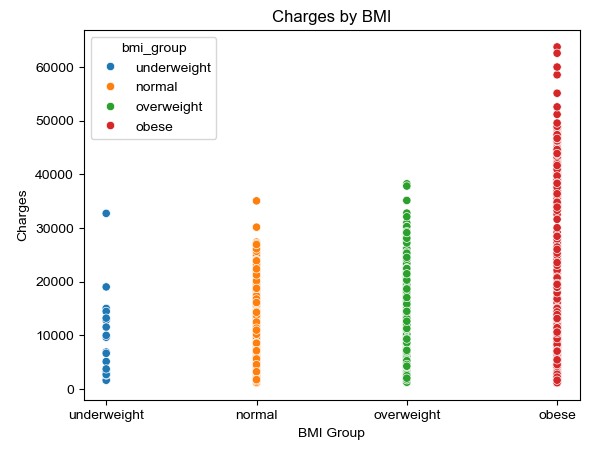

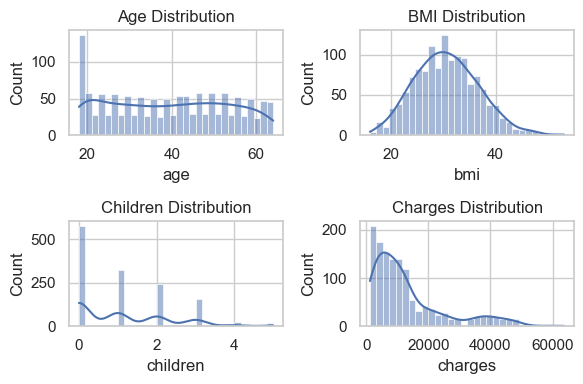

In [25]:
# Setting the aesthetic style of the plots
sns.set(style="whitegrid")

# Plotting distributions of numerical features
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6, 4))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('BMI Distribution')

sns.histplot(df['children'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Children Distribution')

sns.histplot(df['charges'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Charges Distribution')

plt.tight_layout()
save_fig('13_histograms-age-bmi-children-charges')
plt.show()

: The distributions of features:

Age: The distribution appears relatively uniform across different ages, suggesting a fairly even distribution of ages in the dataset.

BMI(Body Mass Index) Shows a distribution that resembles a normal distribution, indicating a typical spread of BMI values among individuals.

Children: The distribution is skewed towards families with fewer children, implying that the majority of individuals in the dataset have fewer children.

Charges: The distribution of charges is highly skewed with a long tail, indicating that while most charges are low, there are some very high charges as well, potentially indicating outliers or extreme cases.

Age and BMI do not appear to have extreme values and are fairly distributed. Moreover, given the discrete nature and lower range of values, Children might not require scaling.

To address the skewness in the Charges feature and standardize the other numerical features (age and BMI), we can consider applying a log transformation to the Charges feature. This transformation can help reduce the skewness and make the distribution more symmetric.

In [26]:
# <> Handling outliers
# define a function to remove the outliers with IQR methods

def detect_outlier(data,treshold=1.5):
    q1 = np.quantile(data,0.25)
    q3 = np.quantile(data,0.75)
    iqr = q3 - q1

    lower_bound = q1 - treshold * iqr
    upper_bound = q3 + treshold * iqr

    return lower_bound,upper_bound

# remove the BMI outlieres with IQR methods and print the outlier
low,up = detect_outlier(df["bmi"])
print(df[(df["bmi"] < low) | (df["bmi"] > up)])
index = df[(df["bmi"] < low) | (df["bmi"] > up)].index
df.drop(index=index,inplace=True)
df.reset_index(drop=True,inplace=True)

      age     sex    bmi  children smoker     region      charges bmi_group
116    58    male  49.06         0     no  southeast  11381.32540     obese
286    46  female  48.07         2     no  northeast   9432.92530     obese
401    47    male  47.52         1     no  southeast   8083.91980     obese
543    54  female  47.41         0    yes  southeast  63770.42801     obese
847    23    male  50.38         1     no  southeast   2438.05520     obese
860    37  female  47.60         2    yes  southwest  46113.51100     obese
1047   22    male  52.58         1    yes  southeast  44501.39820     obese
1088   52    male  47.74         1     no  southeast   9748.91060     obese
1317   18    male  53.13         0     no  southeast   1163.46270     obese


In [27]:
print(df.describe())

#After removing outliers, the BMI distribution appears to be more normally distributed
sns.histplot(df['bmi'], bins=30, kde=True)
save_fig('14_hist-bmi-after-outlier-removal')


               age          bmi     children       charges
count  1328.000000  1328.000000  1328.000000   1328.000000
mean     39.219127    30.537308     1.097139  13221.047810
std      14.042170     5.922176     1.208008  11997.547468
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.220000     0.000000   4744.325050
50%      39.000000    30.300000     1.000000   9369.615750
75%      51.000000    34.488750     2.000000  16604.302645
max      64.000000    46.750000     5.000000  62592.873090


# Does the BMI of males differ significantly from that of females?

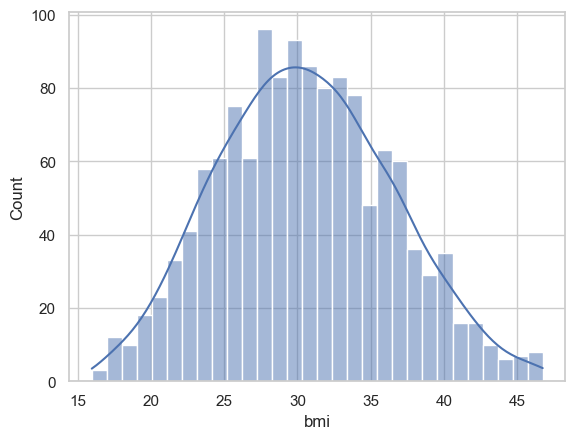

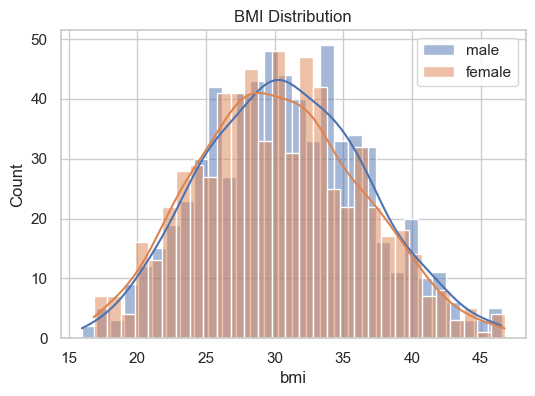

In [28]:

df_males = df[df['sex'] == 'male']
df_females = df[df['sex'] == 'female']

fig, axes = plt.subplots(figsize=(6, 4))

male_plot = sns.histplot(df_males['bmi'], bins=30, kde=True, label = 'male')


female_plot = sns.histplot(df_females['bmi'], bins=30, kde=True,label = 'female')
female_plot.set_title('Female BMI Distribution')

axes.set_title('BMI Distribution')
axes.legend()

plt.show()
#It looks like the BMI distribution between males and females is relatively similar
save_fig('15_hist-bmi-by-sex')


The BMI distribution for males and females looks quite similar and appears to be relatively normally distributed. It appears that the centre of the distribution is around the 30, which aligns well with the analysis done above.

# Is the distribution of BMI across women with no children, one child, and two children, the same?

<Figure size 640x480 with 0 Axes>

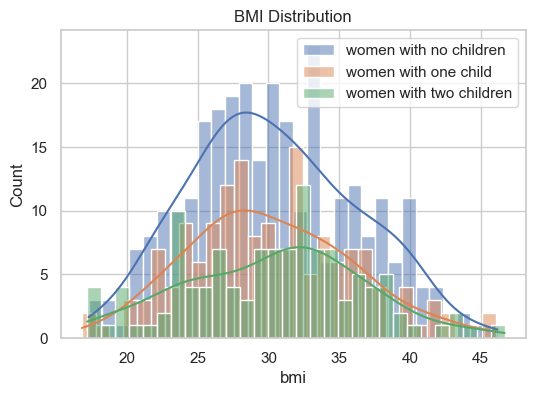

In [29]:
# Code to answer the question of "Is the distribution of BMI across women with no children, one child,
# and two children, the same?"

df_females = df[df['sex'] == 'female']

df_females_0 = df_females[df_females['children'] == 0]
df_females_1 = df_females[df_females['children'] == 1]
df_females_2 = df_females[df_females['children'] == 2]

fig, axes = plt.subplots(figsize=(6, 4))

sns.histplot(df_females_0['bmi'], bins=30, kde=True, label = 'women with no children')
sns.histplot(df_females_1['bmi'], bins=30, kde=True,label = 'women with one child')
sns.histplot(df_females_2['bmi'], bins=30, kde=True,label = 'women with two children')

axes.set_title('BMI Distribution')
axes.legend()

plt.show()
#It appears that women with no children or one child have similar BMI distribution and this is different than
# women with two or three children
save_fig('16_hist-bmi-females-by-children')


In [30]:
# creating a lmplot for women with 0,1,2 children to see if the linear regression is
# different based on the number of children

df_females_0to2 = pd.DataFrame()

df_females_0to2= pd.concat([df_females_0to2, df_females_0])
df_females_0to2= pd.concat([df_females_0to2, df_females_1])
df_females_0to2= pd.concat([df_females_0to2, df_females_2])

_g = sns.lmplot(df_females_0to2, x = 'bmi', y = 'charges', hue = 'children')
save_grid(_g, '17_lmplot-females-bmi-vs-charges-by-children')


In [31]:
# Plotting women smokers with 0,1 and 2 children's bmi vs charges to see if
#there the linear regression is significantly different from one another

df_females_0to2_smoke = df_females_0to2[df_females_0to2['smoker'] == 'yes']
_g = sns.lmplot(df_females_0to2_smoke, x = 'bmi', y = 'charges', hue = 'children')
save_grid(_g, '18_lmplot-female-smokers-bmi-vs-charges')


In [32]:
df_females_0to2_smoke1 = df_females_0to2[df_females_0to2['children'] == 0]
df_females_0to2_smoke1 = df_females_0to2[df_females_0to2['children'] == 1]
#df_females_0to2_smoke1 = df_females_0to2[df_females_0to2['children'] == 2]

_g = sns.lmplot(df_females_0to2_smoke1, x = 'bmi', y = 'charges', hue = 'smoker')
save_grid(_g, '19_lmplot-females-smoker-vs-nonsmoker')


In [33]:
# Looking closer at if there are any linear relationships for women with 0, 1 and 2 children
def examine_trends(df, save_prefix=None):
  fig, axes = plt.subplots(nrows=3, ncols=3,figsize=(9, 9))
  #Regplot "Plot data and a linear regression model fit", so utilizing the linear regression model
  sns.regplot(df, x = 'bmi', y = 'charges', ax = axes[0,0])
  axes[0, 0].set_title('bmi vs. charges')
  sns.regplot(df, x = 'bmi', y = 'age', ax = axes[0,1])
  axes[0, 1].set_title('bmi vs. age')
  sns.histplot(df['smoker'], ax = axes[0,2])

  df_smoke = df[df['smoker'] == 'yes']
  print(df_smoke.head())

  sns.regplot(df_smoke, x = 'bmi', y = 'charges', ax = axes[1,0])
  axes[1,0].set_title('smokers: bmi vs charges')

  sns.histplot(df_smoke['bmi_group'], ax = axes[1,1])
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
  axes[1,1].set_title('smokers: bmi_group')

  sns.histplot(df_smoke['region'], ax = axes[1,2])
  axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=40)
  axes[1,2].set_title('smokers: bmi_group')

  df_nonsmoke = df[df['smoker'] == 'no']
  print(df_nonsmoke.head())

  sns.regplot(df_nonsmoke, x = 'bmi', y = 'charges', ax = axes[2,0])
  axes[2,0].set_title('non-smokers: bmi vs charges')

  sns.histplot(df_nonsmoke['bmi_group'], ax = axes[2,1])
  axes[2,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
  axes[2,1].set_title('non-smokers: region')

  sns.histplot(df_nonsmoke['region'], ax = axes[2,2])
  axes[2,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=40)
  axes[2,2].set_title('non-smokers: region')


  fig.subplots_adjust(wspace=0.4, hspace=1.0)

  if save_prefix:
      fig.savefig(f'images/{save_prefix}.png', dpi=150, bbox_inches='tight')

examine_trends(df_females_0to2, save_prefix='20_trends-grid-female-generic')


    age     sex    bmi  children smoker     region     charges   bmi_group
0    19  female  27.90         0    yes  southwest  16884.9240  overweight
11   62  female  26.29         0    yes  southeast  27808.7251  overweight
64   20  female  22.42         0    yes  northwest  14711.7438      normal
70   27  female  24.75         0    yes  southeast  16577.7795      normal
86   57  female  31.16         0    yes  northwest  43578.9394       obese
    age     sex     bmi  children smoker     region      charges   bmi_group
5    31  female  25.740         0     no  southeast   3756.62160  overweight
9    60  female  25.840         0     no  northwest  28923.13692  overweight
13   56  female  39.820         0     no  southeast  11090.71780       obese
20   60  female  36.005         0     no  northeast  13228.84695       obese
26   63  female  23.085         0     no  northeast  14451.83515      normal


C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,2

In [34]:
# Looking at females with 0 children
examine_trends(df_females_0, save_prefix='21_trends-grid-females-0-children')


    age     sex    bmi  children smoker     region     charges   bmi_group
0    19  female  27.90         0    yes  southwest  16884.9240  overweight
11   62  female  26.29         0    yes  southeast  27808.7251  overweight
64   20  female  22.42         0    yes  northwest  14711.7438      normal
70   27  female  24.75         0    yes  southeast  16577.7795      normal
86   57  female  31.16         0    yes  northwest  43578.9394       obese
    age     sex     bmi  children smoker     region      charges   bmi_group
5    31  female  25.740         0     no  southeast   3756.62160  overweight
9    60  female  25.840         0     no  northwest  28923.13692  overweight
13   56  female  39.820         0     no  southeast  11090.71780       obese
20   60  female  36.005         0     no  northeast  13228.84695       obese
26   63  female  23.085         0     no  northeast  14451.83515      normal


C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,2

In [35]:
examine_trends(df_females_1, save_prefix='22_trends-grid-females-1-child')


     age     sex    bmi  children smoker     region     charges   bmi_group
23    34  female  31.92         1    yes  northeast  37701.8768       obese
58    53  female  22.88         1    yes  southeast  23244.7902      normal
116   29  female  27.94         1    yes  southeast  19107.7796  overweight
260   20  female  26.84         1    yes  southeast  17085.2676  overweight
279   40  female  28.12         1    yes  northeast  22331.5668  overweight
    age     sex     bmi  children smoker     region      charges   bmi_group
6    46  female  33.440         1     no  southeast   8240.58960       obese
16   52  female  30.780         1     no  northeast  10797.33620       obese
21   30  female  32.400         1     no  southwest   4149.73600       obese
63   28  female  25.935         1     no  northwest   4133.64165  overweight
76   29  female  29.590         1     no  southeast   3947.41310  overweight


C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,2

In [36]:
# Looking at females with 2 children
examine_trends(df_females_2, save_prefix='23_trends-grid-females-2-children')


     age     sex     bmi  children smoker     region     charges    bmi_group
84    37  female  34.800         2    yes  southwest  39836.5190        obese
94    64  female  31.300         2    yes  southwest  47291.0550        obese
127   32  female  17.765         2    yes  northwest  32734.1863  underweight
234   40  female  22.220         2    yes  southeast  19444.2658       normal
239   23  female  36.670         2    yes  northeast  38511.6283        obese
    age     sex     bmi  children smoker     region      charges bmi_group
27   55  female  32.775         2     no  northwest  12268.63225     obese
41   31  female  36.630         2     no  southeast   4949.75870     obese
43   37  female  30.800         2     no  southeast   6313.75900     obese
46   18  female  38.665         2     no  northeast   3393.35635     obese
51   21  female  33.630         2     no  northwest   3579.82870     obese


C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=40)
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\3219715280.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,2

Based on the above examination of the linear relationships for women with 0, 1 and 2 children, there are some notable observations.

When looking at the combined data for women with 0, 1 and 2 children, there is a low positive correlation between bmi and charges as well as bmi and age. Smokers have a strong positive correlation between bmi and charges and majority seem to be overweight or obese. When plotting the bmi vs. charges for women with 0, 1 and 2 children, it appears that women with 2 children incure slightly higher charges compared to women with 0 or 1 child.

For women with 0 children, as BMI increases, so does the charges. This appears to be consistent and could serve as a strong predictor. There is low positive correlation between bmi and age. Majority of women with 0 children are non-smokers and there doesn't appear to be any notable trends for non-smokers. For smokers wtih 0 children, there is a strong positive correlation between bmi and charges as well as a majority being overweight and obese, which are consistent findings.

For women with 1 children, as bmi increases so does the charges. We can also observe that for women with 1 children, as bmi increases so does the age. Similar to women with 0 children, smokers have strong correlation between bmi and charges, majority being overweight or obese and interestingly, reside in the northeast region.

For women with 2 children, there is weak positive correlation between bmi and charges as well as between bmi and age. For non-smokers, there is weak positive correlation between bmi and charges, majority being obese or overweight and even distribution among the regions. For smokers, there is a very strong correlation between bmi and charges, majority being overweight or obese and again, even distribution among the regions.

Based on the above, the findings are very consistent with the above analysis, that there is a strong relationship between bmi and charges, where one could predict that for an overweight individual that smokes, they are likely to incure high charges.

<Figure size 640x480 with 0 Axes>

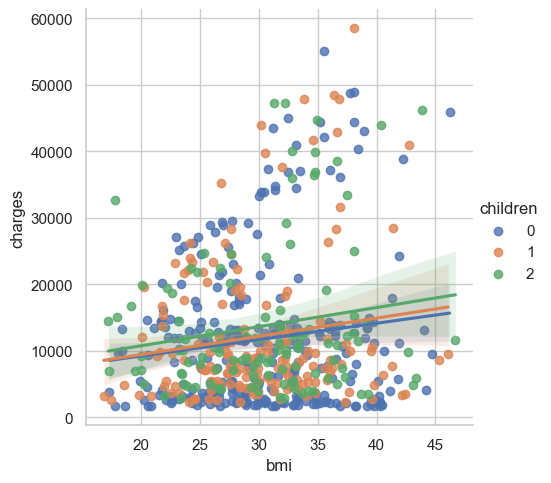

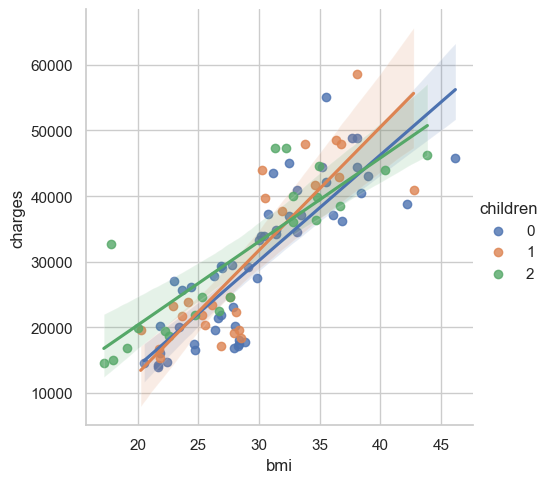

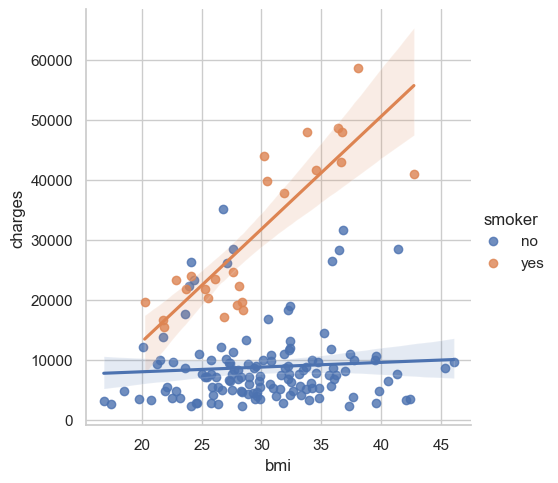

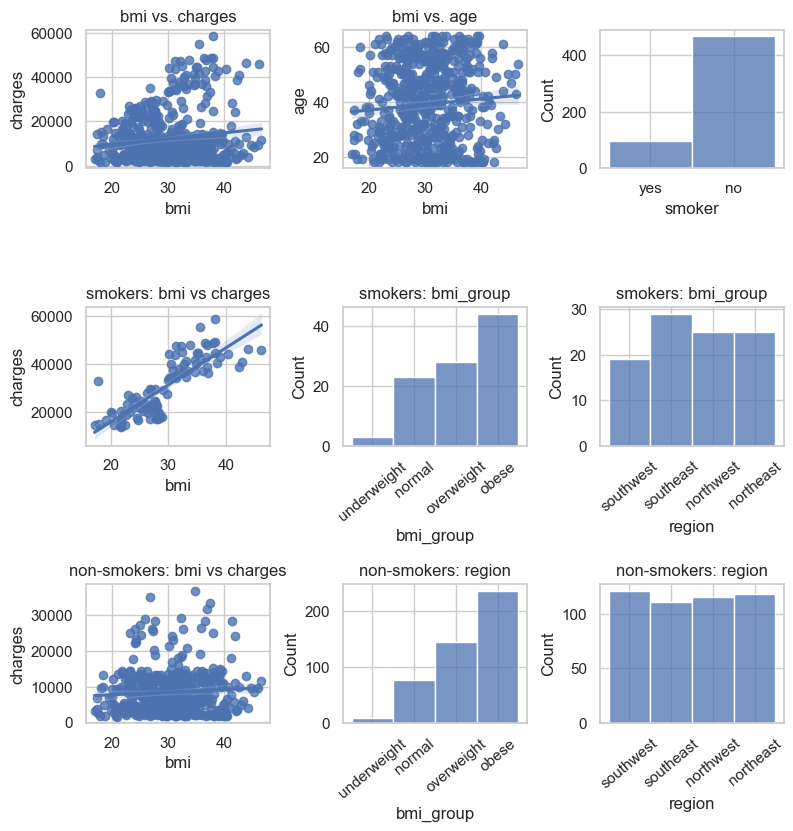

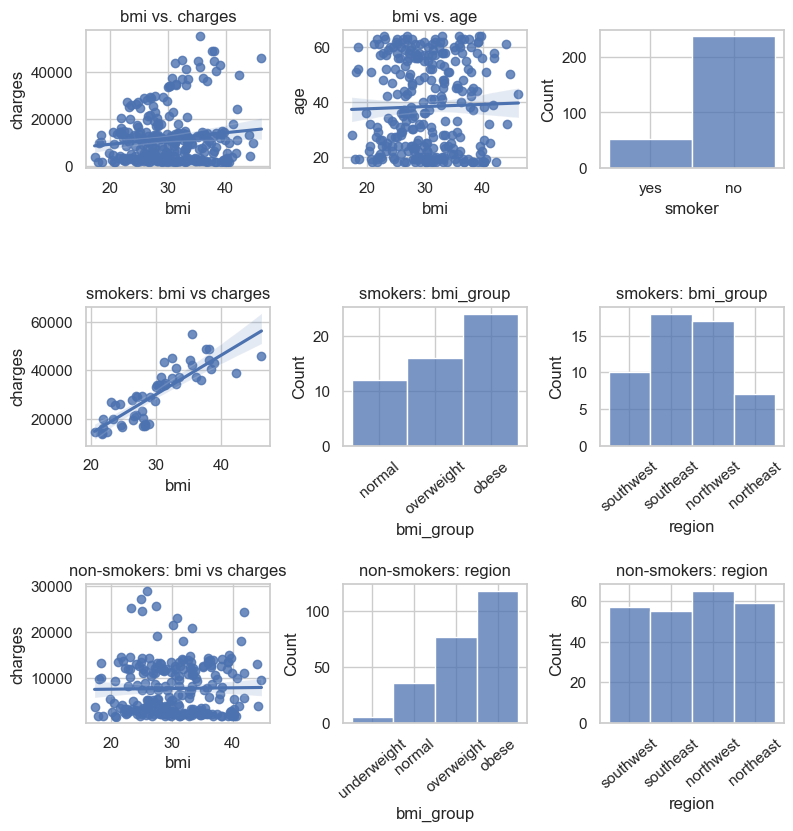

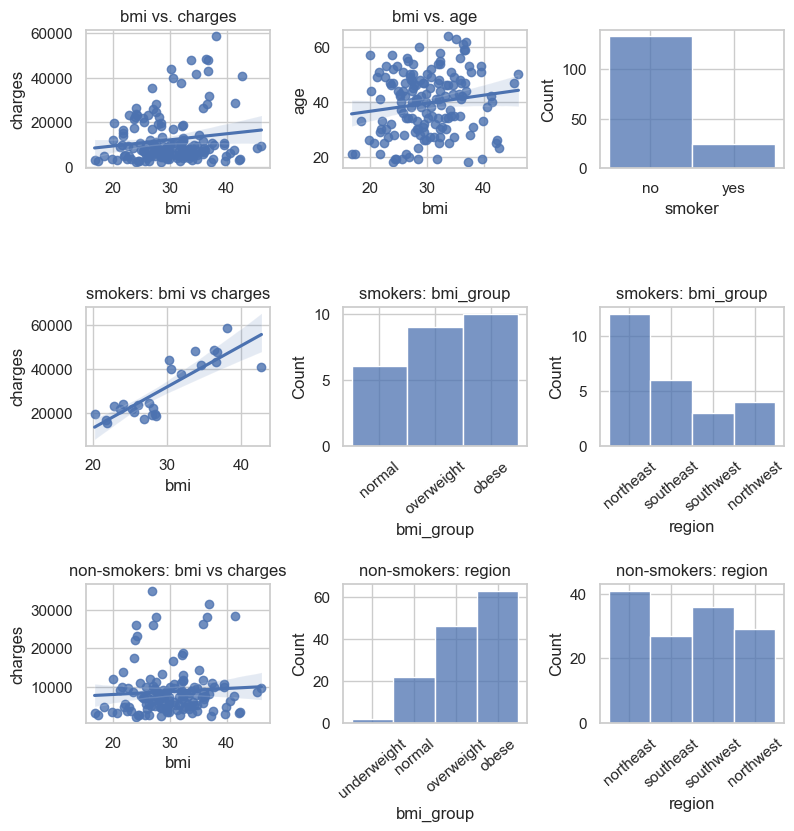

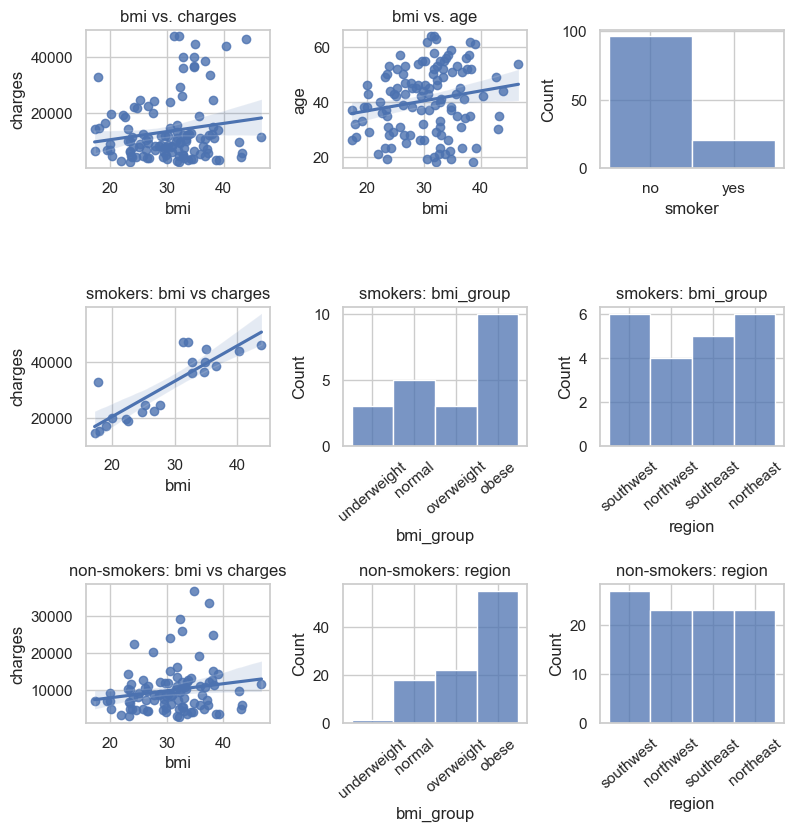

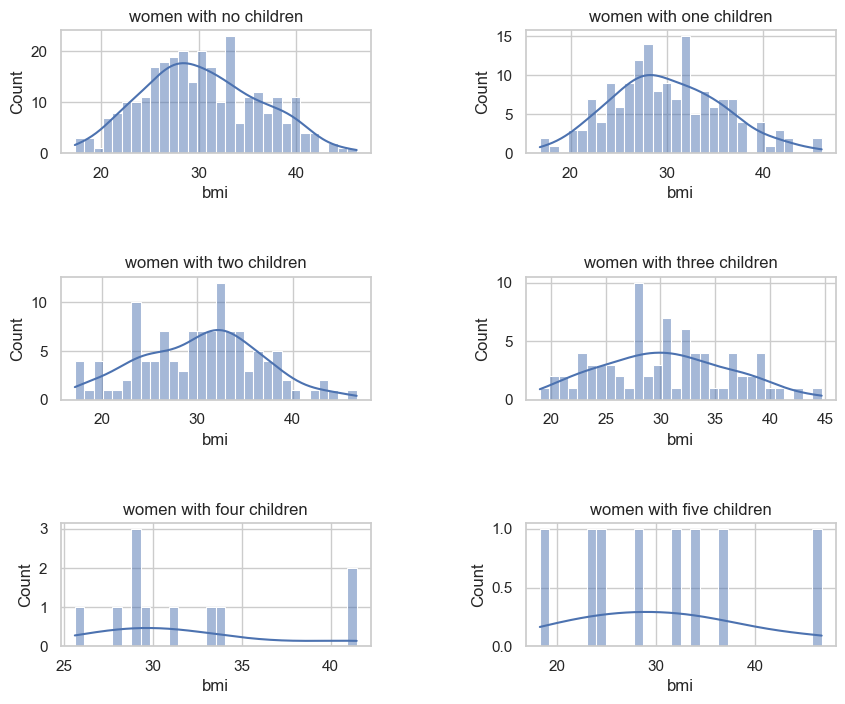

In [37]:
# reformatted code above to display individual bmi distributions charts
df_females_3 = df_females[df_females['children'] == 3]
df_females_4 = df_females[df_females['children'] == 4]
df_females_5 = df_females[df_females['children'] == 5]

fig, axes = plt.subplots(nrows=3, ncols=2,figsize=(10, 8))

sns.histplot(df_females_0['bmi'], bins=30, kde=True, label = 'women with no children',ax=axes[0, 0])
axes[0, 0].set_title('women with no children')
sns.histplot(df_females_1['bmi'], bins=30, kde=True,label = 'women with one child',ax=axes[0, 1])
axes[0, 1].set_title('women with one children')
sns.histplot(df_females_2['bmi'], bins=30, kde=True,label = 'women with two children',ax=axes[1, 0])
axes[1, 0].set_title('women with two children')
sns.histplot(df_females_3['bmi'], bins=30, kde=True,label = 'women with three children',ax=axes[1, 1])
axes[1, 1].set_title('women with three children')
sns.histplot(df_females_4['bmi'], bins=30, kde=True,label = 'women with four children',ax=axes[2, 0])
axes[2, 0].set_title('women with four children')
sns.histplot(df_females_5['bmi'], bins=30, kde=True,label = 'women with five children',ax=axes[2, 1])
axes[2, 1].set_title('women with five children')

fig.subplots_adjust(wspace=0.5, hspace=1)
save_fig('24_hist-bmi-females-by-children-all')
plt.show()

# Looking at charges distribution among Female and Male smokers.

In [38]:
# found an interesting difference between male and female smokers and thought to include it in the code
df_smokers_m = df_males[df_males['smoker'] == 'yes']

df_smokers_f = df_females[df_females['smoker'] == 'yes']

fig, axes = plt.subplots(figsize=(4, 4))
sns.histplot(df_smokers_f['charges'], bins=30, kde=True,label = 'female smokers')
sns.histplot(df_smokers_m['charges'], bins=30, kde=True, label = 'male smokers')

axes.set_title('Smokers distribution')
axes.legend()
#between male and female smokers, there does look to be some different in the distribution
#for female smokers, the frequency of lower charges appears to be higher
# whereas for male smokers, there is higher frequency of higher charges
save_fig('25_hist-smokers-charges-by-sex')


In [39]:
#<>:
df_smokers = df[df['smoker'] == 'yes']

df_smokers_m = df_smokers[df_smokers['sex']== 'male']
df_smokers_f = df_smokers[df_smokers['sex']== 'female']

# fixed: mask now derives from the same DF being filtered (was df_smokers on both, which triggered
# a pandas reindex warning and silently relied on index alignment)
df_smokers_m_obese = df_smokers_m[df_smokers_m['bmi_group']== 'obese']
df_smokers_f_obese = df_smokers_f[df_smokers_f['bmi_group']== 'obese']


fig, axes = plt.subplots(figsize=(4, 4))
sns.histplot(df_smokers_m_obese['charges'], bins=30, kde=True,label = 'male smokers')
sns.histplot(df_smokers_f_obese['charges'], bins=30, kde=True, label = 'female smokers')

axes.set_title('Obese smokers charges distribution by sex')
axes.legend()
save_fig('26_hist-obese-smokers-charges-by-sex')


: Our analysis of the distribution of premium charges among male and female smokers reveals interesting insights. While both male and female smokers exhibit a normal distribution of premium charges, there is a notable difference in the kurtosis between the two groups.A positive kurtosis indicates a relatively peaked distribution with heavier tails, while a negative kurtosis suggests a flatter distribution with lighter tails.In this case, we observe that the distribution of premium charges among male smokers is more leptokurtic, meaning it has fatter tails and a higher peak compared to a normal distribution. This indicates that there is a higher concentration of premium charges around the mean, with fewer extreme values.On the other hand, the distribution of premium charges among female smokers appears to be closer to a normal distribution, with less pronounced tails and a slightly lower peak. This suggests a distribution that is more spread out, with a greater likelihood of extreme values compared to the male smoker group.Overall, the observed differences in kurtosis highlight the importance of considering gender-specific factors when analyzing insurance data and designing pricing models. By understanding the nuances of distribution characteristics, insurers can better tailor their offerings to meet the unique needs and risk profiles of different demographic groups.

In [40]:
# Plotting male smoker age against charges, and we can see there is a positive correlation for age and charges. As age increases, so do charges as well as obese male smokers
# being charged the highest.

#keeping sex and smoker status consistent, looking at the other variables: age, bmi/bmi_group, children and region
print(df_smokers_m.head())

_g = sns.lmplot(df_smokers_m, x ='age', y = 'charges', hue = 'bmi_group')
save_grid(_g, '27_male-smokers-charges-by-age-bmigroup')

_g = sns.lmplot(df_smokers_m, x ='age', y = 'charges', hue = 'children')
save_grid(_g, '28_male-smokers-charges-by-age-children')
#There does not appear to be any noticable trends for age vs. charges when the data is divided based on the
#number of children a male smoker has.
#This could suggest the number of children an individual as does not have that much effect on the charges they incure.

_g = sns.lmplot(df_smokers_m, x ='age', y = 'charges', hue = 'region')
save_grid(_g, '29_male-smokers-charges-by-age-region')

_g = sns.lmplot(df_smokers_m, x ='bmi', y = 'charges', hue = 'region')
save_grid(_g, '30_male-smokers-charges-by-bmi-region')
#for male smokers, it looks like individuals that reside in the southeast region incure slightly higher charges
#compared to the other regions.


    age   sex    bmi  children smoker     region      charges bmi_group
14   27  male  42.13         0    yes  southeast  39611.75770     obese
19   30  male  35.30         0    yes  southwest  36837.46700     obese
29   31  male  36.30         2    yes  southwest  38711.00000     obese
30   22  male  35.60         0    yes  southwest  35585.57600     obese
34   28  male  36.40         1    yes  southwest  51194.55914     obese


# Does the region have an impact on charges?

In [41]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_group
0,19,female,27.900,0,yes,southwest,16884.92400,overweight
1,18,male,33.770,1,no,southeast,1725.55230,obese
2,28,male,33.000,3,no,southeast,4449.46200,obese
3,33,male,22.705,0,no,northwest,21984.47061,normal
4,32,male,28.880,0,no,northwest,3866.85520,overweight


In [42]:
# Dividing up the dataframe into subsets based on the region, then looking at the linear relationships
df_se = df[df['region'] == 'southeast']
df_sw = df[df['region'] == 'southwest']
df_ne = df[df['region'] == 'northeast']
df_nw = df[df['region'] == 'northwest']

def lmplot_regions(df, save_prefix=None):
  #looking at bmi vs. charges
  _g1 = sns.lmplot(df, x = 'bmi', y = 'charges', hue = 'sex')
  _g2 = sns.lmplot(df, x = 'bmi', y = 'charges', hue = 'smoker')
  #looking at age vs. charges
  _g3 = sns.lmplot(df, x = 'age', y = 'charges', hue = 'sex')
  _g4 = sns.lmplot(df, x = 'age', y = 'charges', hue = 'smoker')
  _g5 = sns.lmplot(df, x = 'age', y = 'charges', hue = 'bmi_group')

  if save_prefix:
      save_grid(_g1, f'{save_prefix}_1_bmi-charges-by-sex')
      save_grid(_g2, f'{save_prefix}_2_bmi-charges-by-smoker')
      save_grid(_g3, f'{save_prefix}_3_age-charges-by-sex')
      save_grid(_g4, f'{save_prefix}_4_age-charges-by-smoker')
      save_grid(_g5, f'{save_prefix}_5_age-charges-by-bmigroup')


In [43]:
lmplot_regions(df_se, save_prefix='31_southeast')


In [44]:
lmplot_regions(df_sw, save_prefix='36_southwest')


In [45]:
lmplot_regions(df_ne, save_prefix='41_northeast')


c:\Users\Aiga\anaconda3\Lib\site-packages\seaborn\axisgrid.py:453: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=figsize)


In [46]:
lmplot_regions(df_nw, save_prefix='46_northwest')


In [47]:
_g = sns.pairplot(df,kind = 'reg', height = 2, hue="smoker")
save_grid(_g, '51_pairplot-all-by-smoker')


: Age is the independent variable and charges is dependent variable. There is a linearly increasing relationship between age and insurance charges. Older people are tend to be charged more.

: BMI is the independent variable and charges is dependent variable

: smokers are charged way higher than non-smokers

In [48]:
# see all possible linear relationships for males
_g = sns.pairplot(df_males,kind = 'reg', height = 2, hue="smoker")
save_grid(_g, '52_pairplot-males-by-smoker')


In [49]:
# see all possible linear relationships for females
_g = sns.pairplot(df_females,kind = 'reg', height = 2, hue="smoker")
save_grid(_g, '53_pairplot-females-by-smoker')


# Additional Analysis:

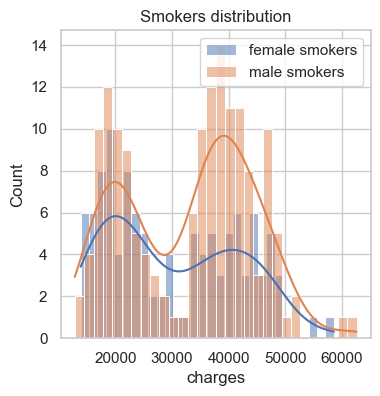

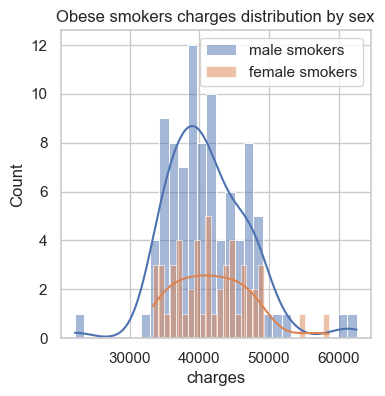

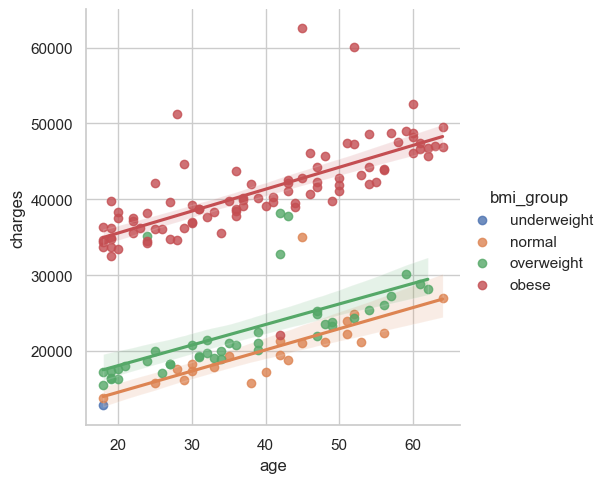

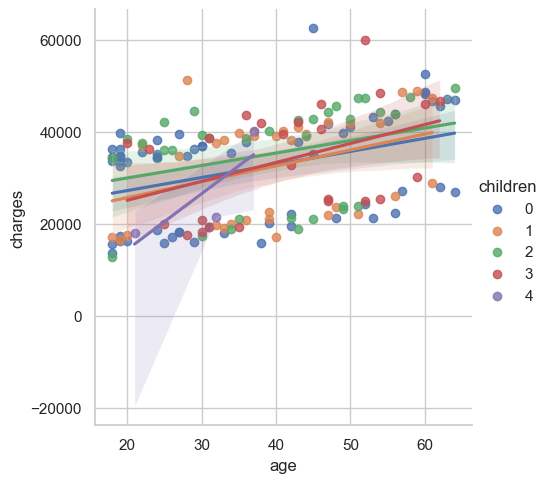

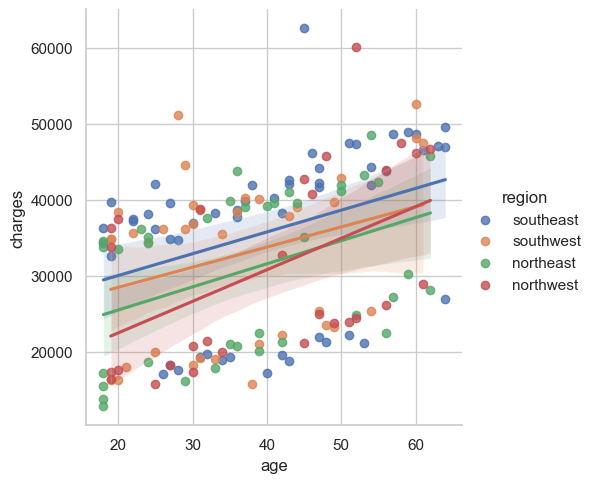

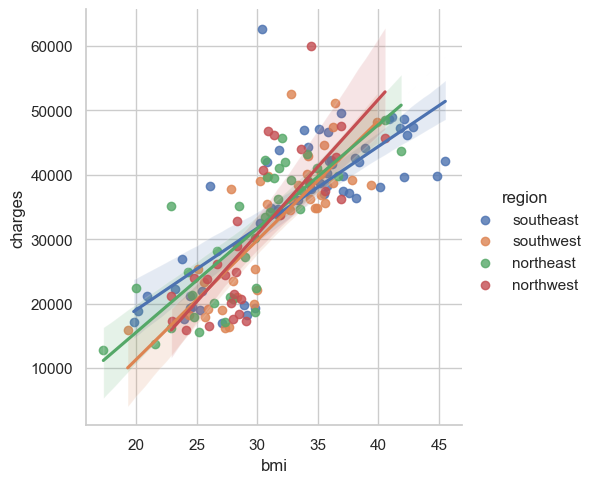

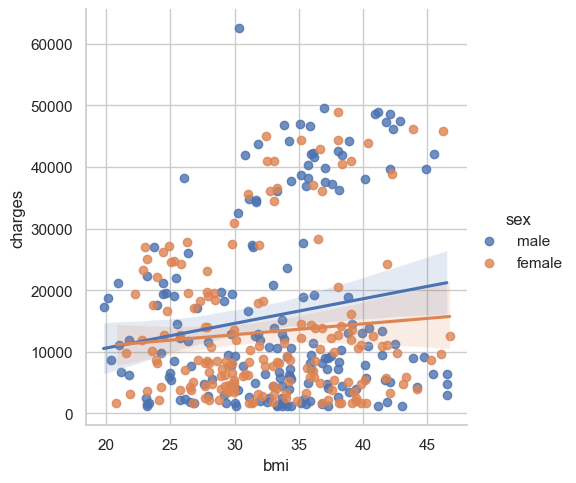

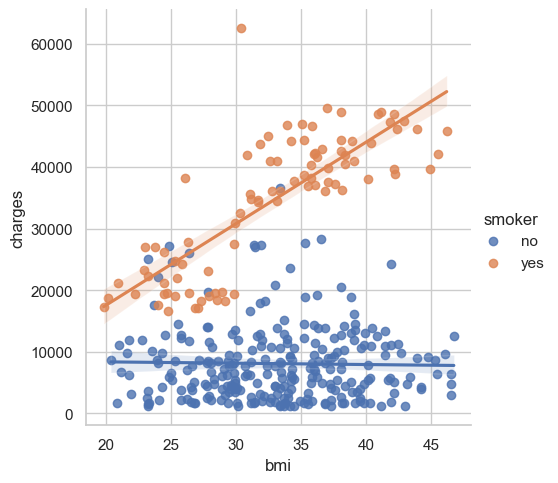

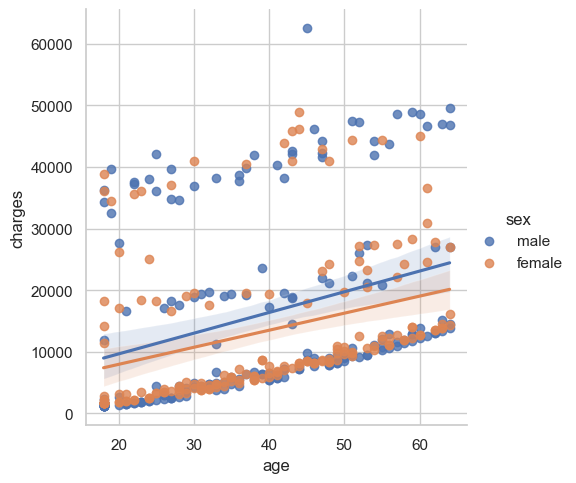

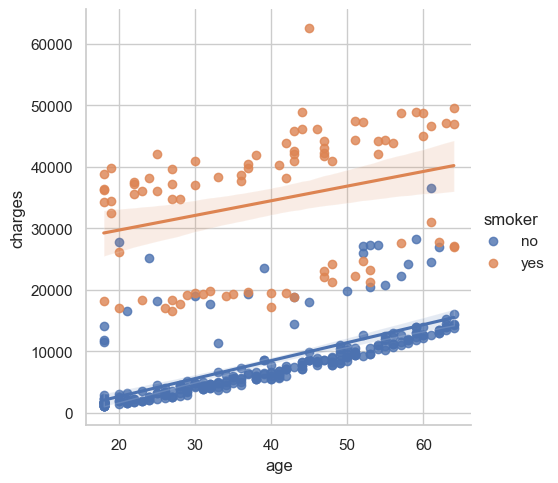

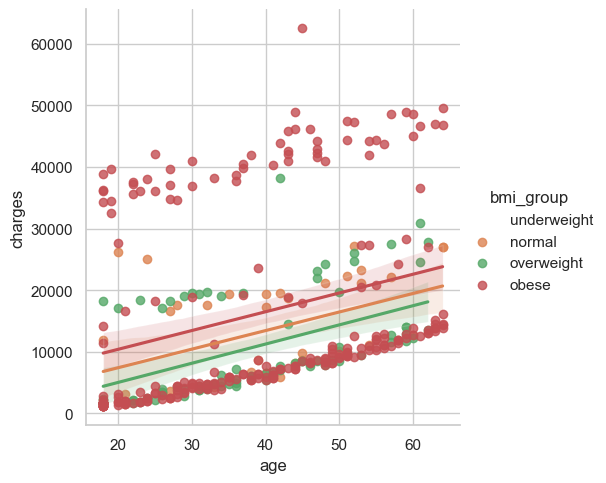

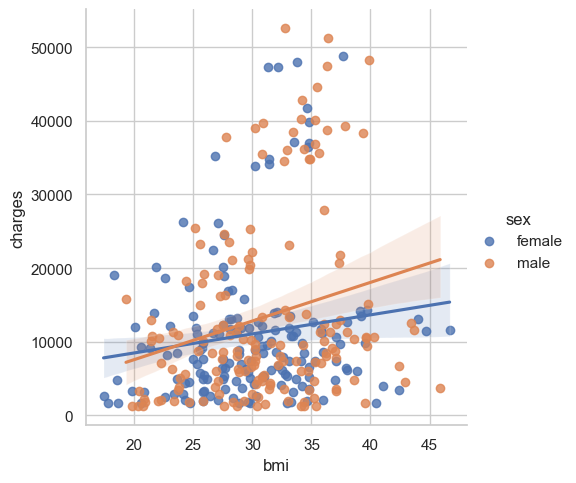

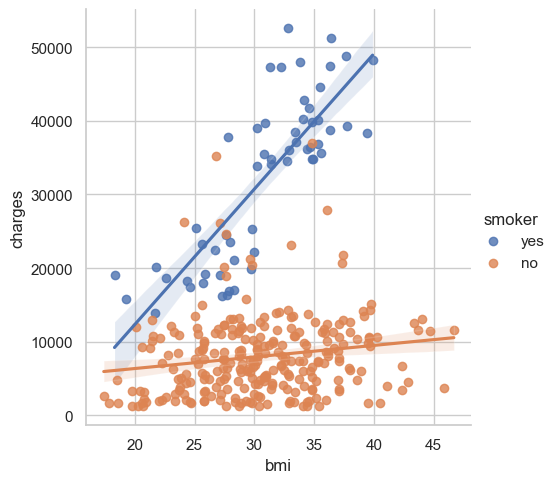

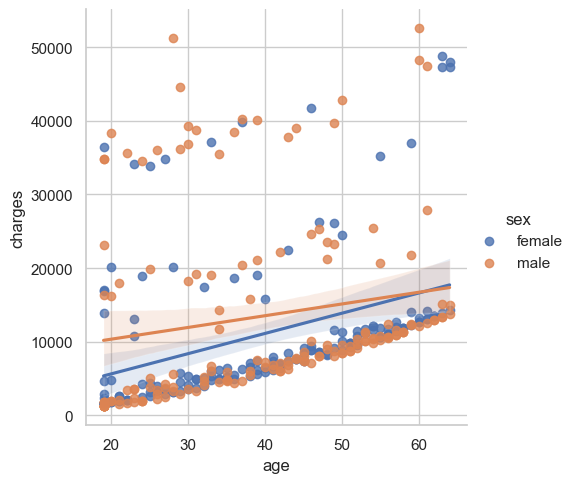

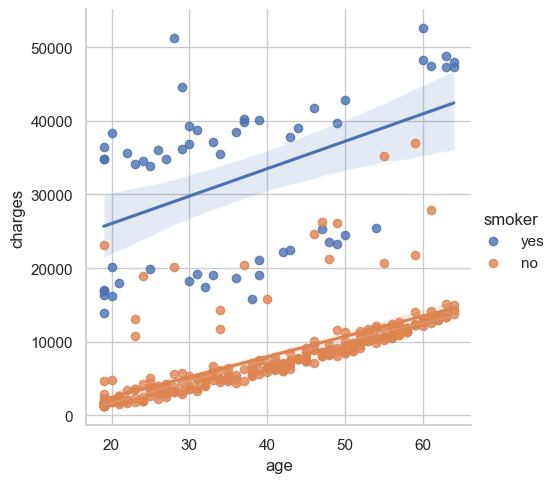

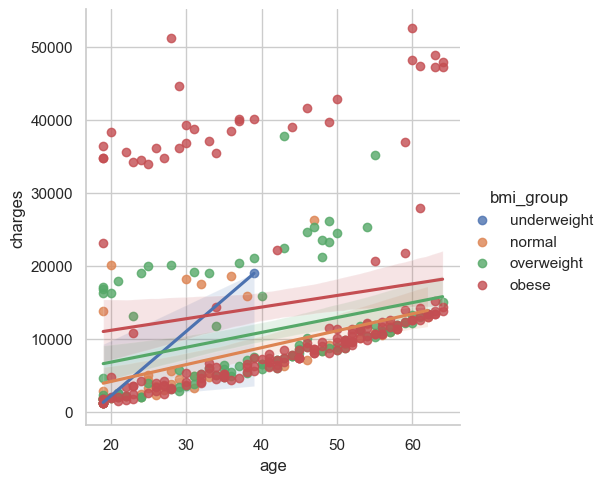

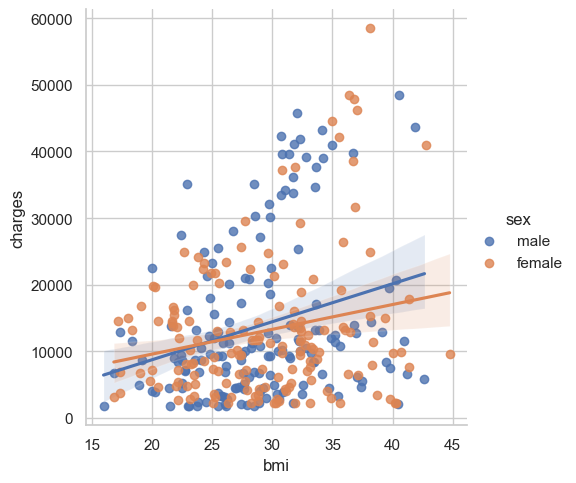

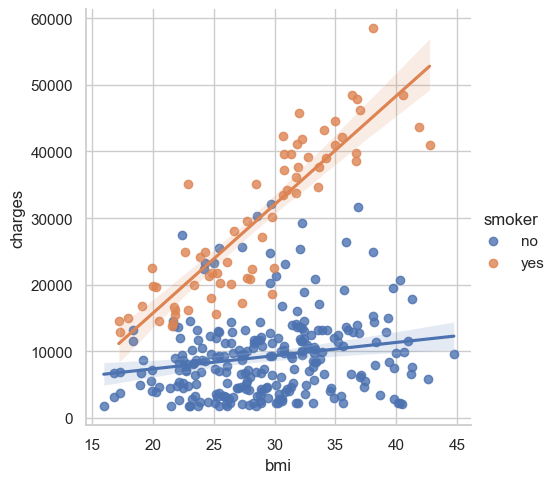

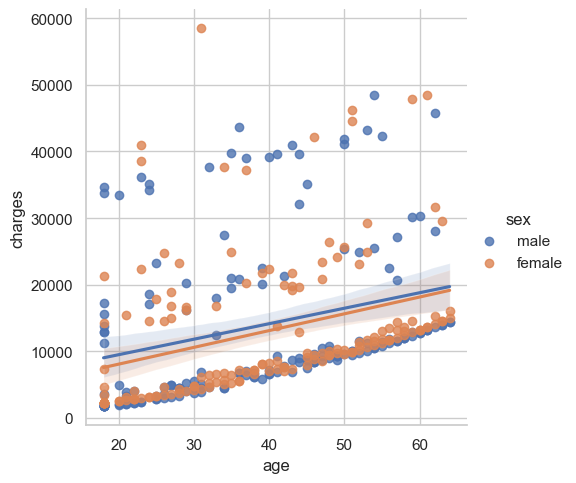

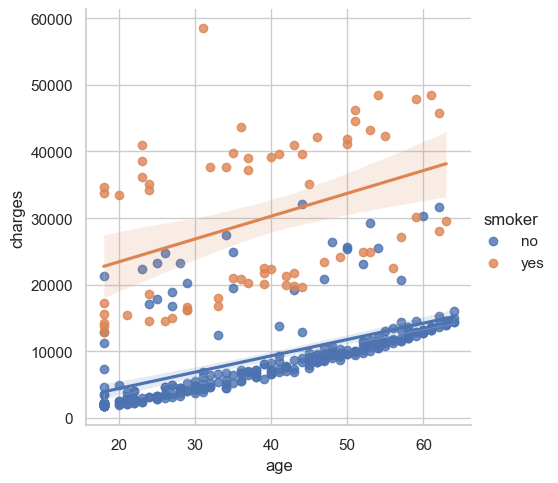

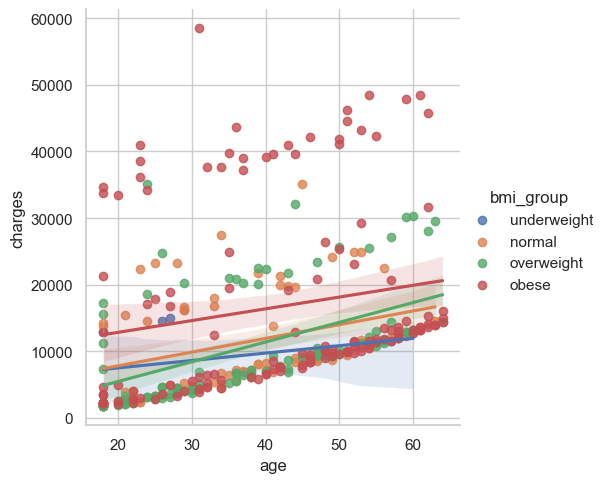

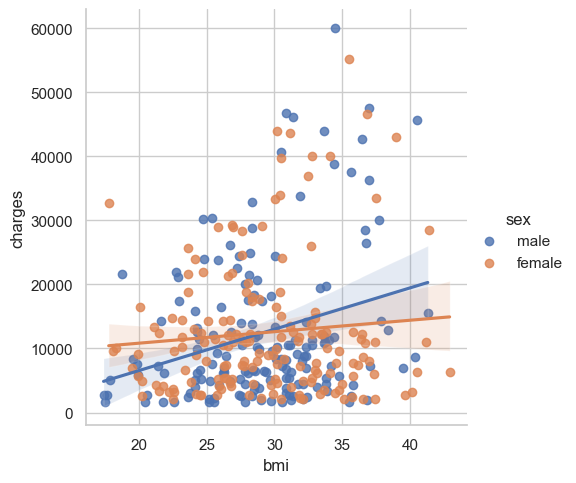

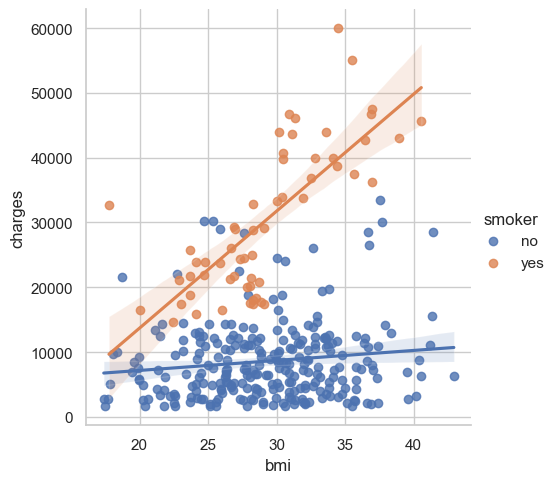

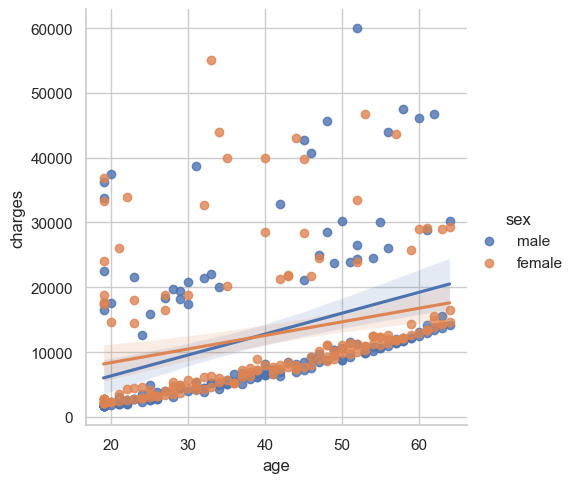

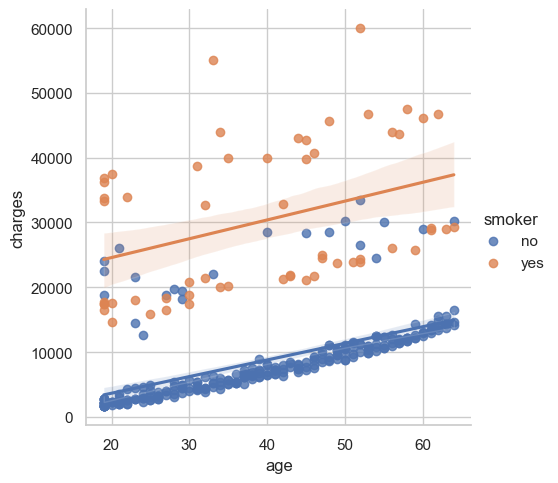

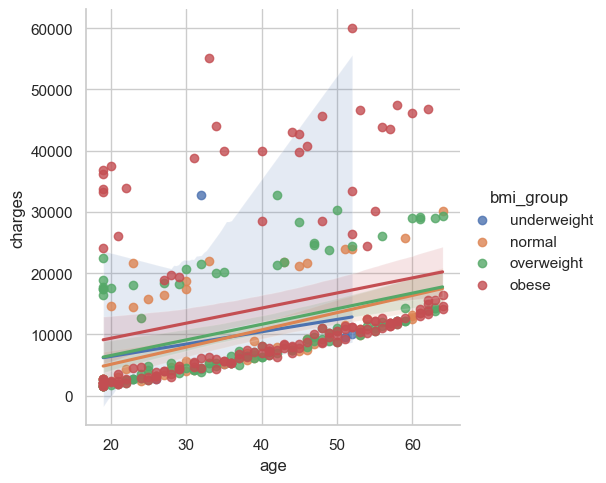

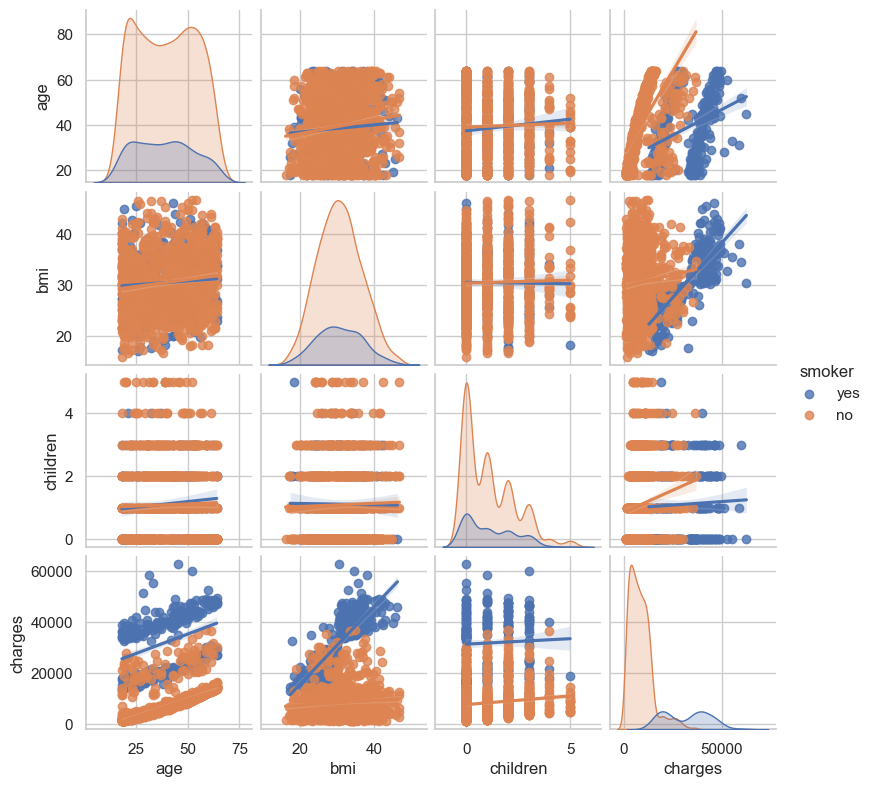

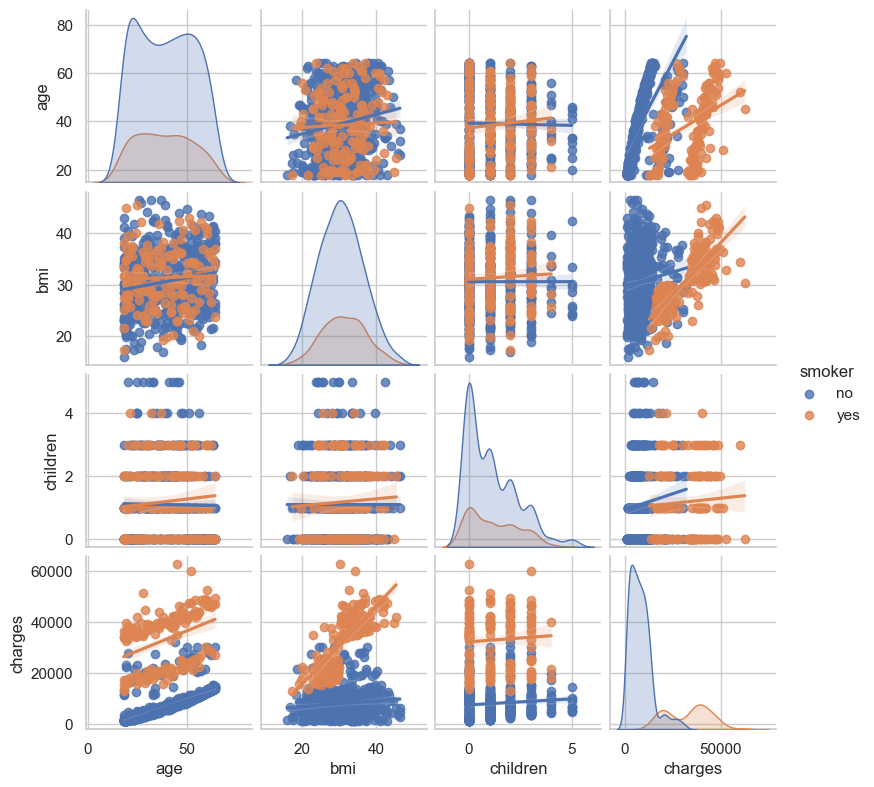

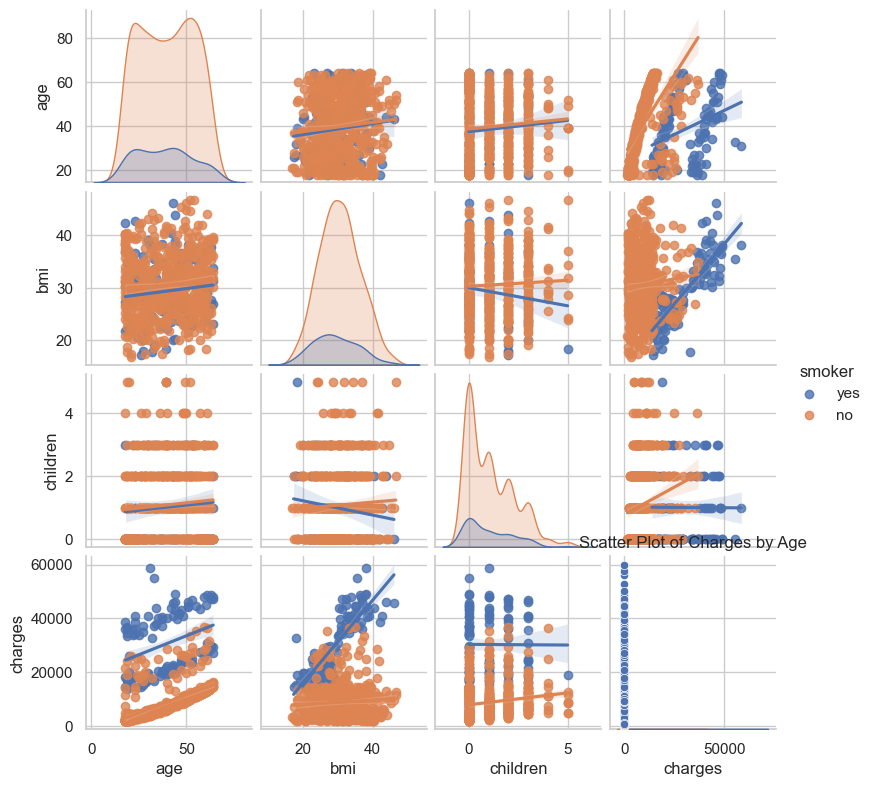

In [50]:
with sns.axes_style("whitegrid"):
    sns.scatterplot(x=df['age'], y=df['charges'])
    plt.xlabel('Age')
    plt.ylabel('Charges (USD)')
    plt.title('Scatter Plot of Charges by Age')

save_fig('54_scatter-charges-by-age')
plt.show()

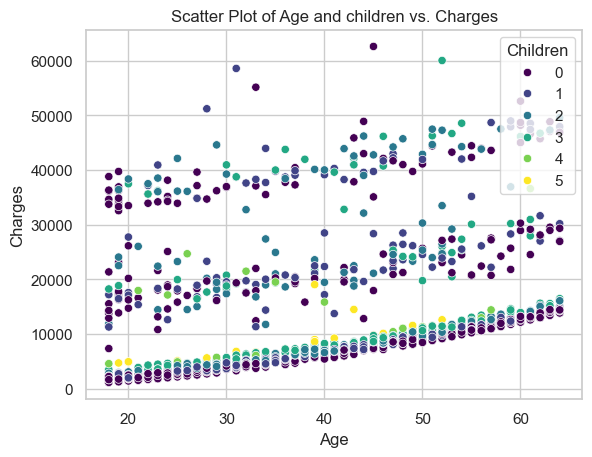

In [51]:
# <> plotting charges by age and children
sns.scatterplot(x=df['age'], y=df['charges'], hue=df['children'], hue_norm=(0, 5), palette = 'viridis', legend="full")
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Scatter Plot of Age and children vs. Charges')
plt.legend(title='Children', loc='upper right')

save_fig('55_scatter-charges-by-age-children')
plt.show()

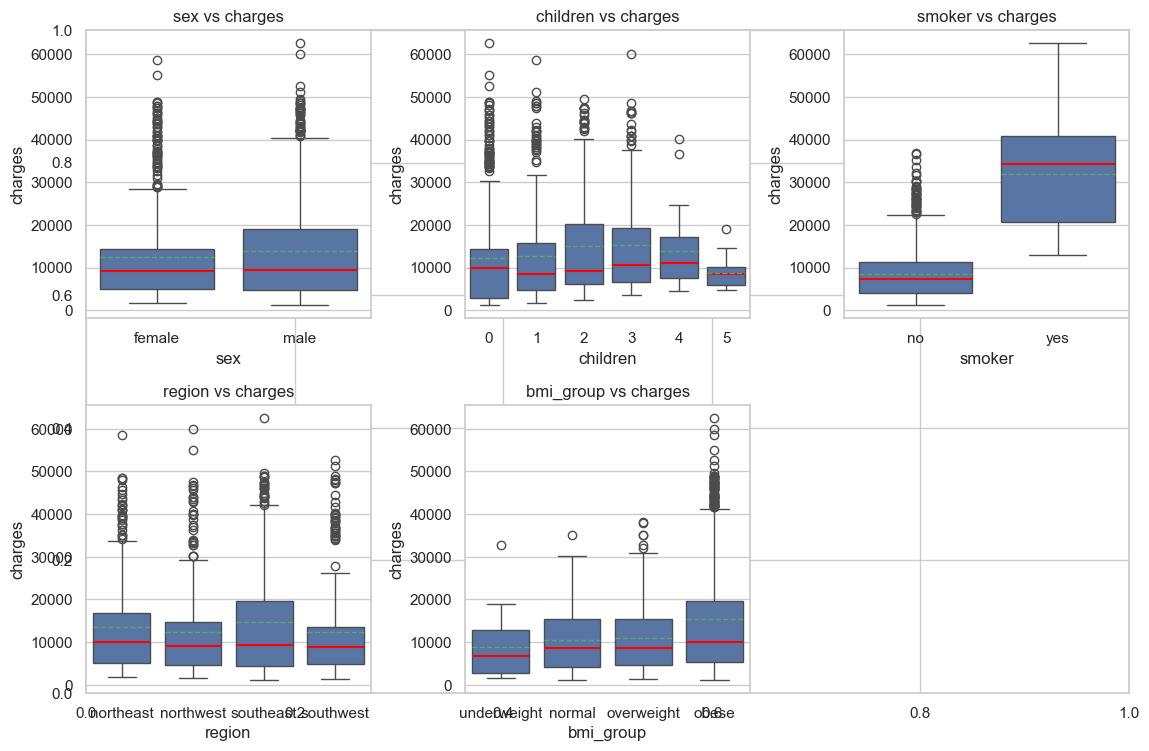

In [52]:
# <>
fig, ax = plt.subplots(figsize=(12, 8))
for i, col in enumerate([col for col in df.columns if df[col].nunique() <= 6], 1):
    plt.subplot(2, 3, i)

    ax = sns.boxplot(data=df, x=df[col].astype('category'), y='charges', showmeans = True, meanline = True, medianprops = dict(color = "red", linewidth = 1.5))
    plt.title(f'{col} vs charges')

plt.tight_layout()
save_fig('56_boxplot-charges-by-categoricals-v2')
plt.show()

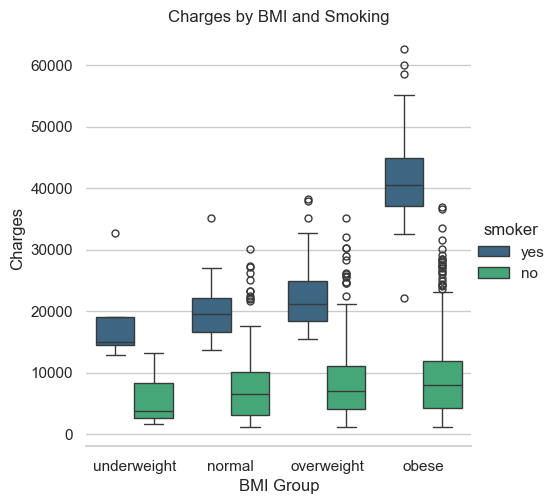

In [53]:
# <> plotting charges by BMI group and smoking
sns.catplot(data=df,
            x="bmi_group", y="charges", hue="smoker", kind="box", palette="viridis")

sns.despine(left=True)
plt.xlabel('BMI Group')
plt.ylabel('Charges')
plt.title('Charges by BMI and Smoking')
save_fig('57_boxplot-charges-by-bmigroup-smoker')
plt.show()

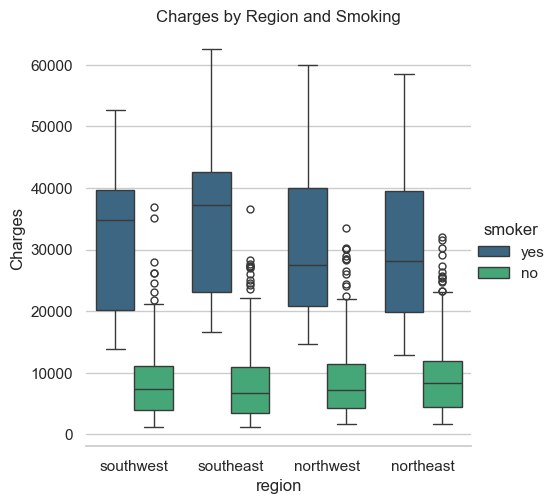

In [54]:
# <> plotting charges by Region and smoking
sns.catplot(data=df,
            x="region", y="charges", hue="smoker", kind="box", palette="viridis")

sns.despine(left=True)
plt.xlabel('region')
plt.ylabel('Charges')
plt.title('Charges by Region and Smoking')
save_fig('58_boxplot-charges-by-region-smoker')
plt.show()

In [55]:
#<> plot the barplot on number of children
fig , ax = plt.subplots()
df["children"].value_counts().plot(kind="bar",ax=ax,colormap="plasma")
ax.grid(axis="y",ls="--",color="gray")
ax.set(ylabel="counts",title="Number of Children");
save_fig('59_barplot-children-count')


# SECTION 2.1: correlation

In [56]:
# <>
df_cleaned = df

df_cleaned['age_group'] = pd.cut(df_cleaned['age'], bins=[0, 25, 40, 60, df_cleaned['age'].max()], labels=['Young', 'Adult', 'Middle-aged', 'Senior'])
df_cleaned.sample(5)

,age,sex,bmi,children,smoker,region,charges,bmi_group,age_group
3,33,male,22.705,0,no,northwest,21984.47061,normal,Adult
152,42,female,23.370,0,yes,northeast,19964.74630,normal,Middle-aged
1021,54,male,31.600,0,no,southwest,9850.43200,obese,Middle-aged
101,30,male,25.460,0,no,northeast,3645.08940,overweight,Adult
13,56,female,39.820,0,no,southeast,11090.71780,obese,Middle-aged


In [57]:
# <>
df_encoded = pd.get_dummies(df_cleaned, columns=['region'], prefix='region', dtype=int)
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest
351,33,male,35.245,0,no,12404.87910,obese,Adult,1,0,0,0
796,64,female,35.970,0,no,14313.84630,obese,Senior,0,0,1,0
186,30,female,30.900,3,no,5325.65100,obese,Adult,0,0,0,1
31,18,female,26.315,0,no,2198.18985,overweight,Young,1,0,0,0
815,45,male,33.700,1,no,7445.91800,obese,Middle-aged,0,0,0,1


In [58]:
# <>
label_encoder = LabelEncoder()
df_encoded['smoker_encoded'] = label_encoder.fit_transform(df_encoded['smoker'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
495,44,female,23.980,2,no,8211.10020,normal,Middle-aged,0,0,1,0,0
1277,28,female,17.290,0,no,3732.62510,underweight,Adult,1,0,0,0,0
565,48,male,40.565,2,yes,45702.02235,obese,Middle-aged,0,1,0,0,1
634,56,male,33.660,4,no,12949.15540,obese,Middle-aged,0,0,1,0,0
712,60,male,24.320,1,no,13112.60480,normal,Middle-aged,0,1,0,0,0


In [59]:
# <>
df_encoded['sex_encoded'] = label_encoder.fit_transform(df_encoded['sex'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
1277,28,female,17.290,0,no,3732.62510,underweight,Adult,1,0,0,0,0,0
727,24,female,30.100,3,no,4234.92700,obese,Young,0,0,0,1,0,0
1037,55,male,35.245,1,no,11394.06555,obese,Middle-aged,1,0,0,0,0,1
787,22,female,23.180,0,no,2731.91220,normal,Young,1,0,0,0,0,0
542,28,male,35.435,0,no,3268.84665,obese,Adult,1,0,0,0,0,1


In [60]:
# <>
df_encoded = df_encoded[[x for x in df_encoded.columns if x not in ['smoker', 'sex']]]
df_encoded.sample(5)

,age,bmi,children,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
1069,21,26.030,0,2102.26470,overweight,Young,1,0,0,0,0,1
1104,28,26.315,3,5312.16985,overweight,Adult,0,1,0,0,0,0
1027,61,38.380,0,12950.07120,obese,Senior,0,1,0,0,0,1
320,34,30.800,0,35491.64000,obese,Adult,0,0,0,1,1,1
376,64,30.115,3,16455.70785,obese,Senior,0,1,0,0,0,0


In [61]:
#<; April 8>
df_cat=df.drop(['bmi_group','age_group'], axis = 1)
df_cat.head()
# Convert object labels to categorical data type
df_cat[['sex', 'region', 'smoker']] = df_cat[['sex', 'region', 'smoker']].astype('category')

# Check the updated data types
print(df_cat.dtypes)
# Converting category labels into numerical using LabelEncoder
from sklearn import preprocessing
label = preprocessing.LabelEncoder()

label.fit(df_cat.sex.drop_duplicates())
df_cat.sex = label.transform(df_cat.sex)

label.fit(df_cat.smoker.drop_duplicates())
df_cat.smoker = label.transform(df_cat.smoker)

label.fit(df_cat.region.drop_duplicates())
df_cat.region = label.transform(df_cat.region)

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object


In [62]:
#<; April 8>
plt.figure(figsize=(6,4))
sns.heatmap(df_cat.corr(),cmap='coolwarm',annot=True)
save_fig('60_heatmap-correlation-categorical')


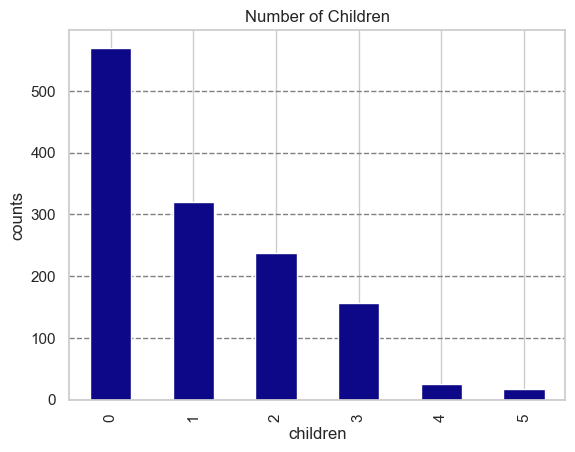

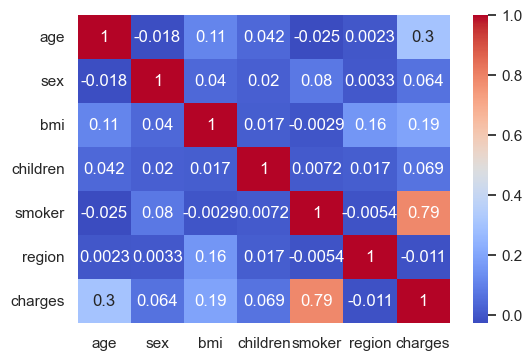

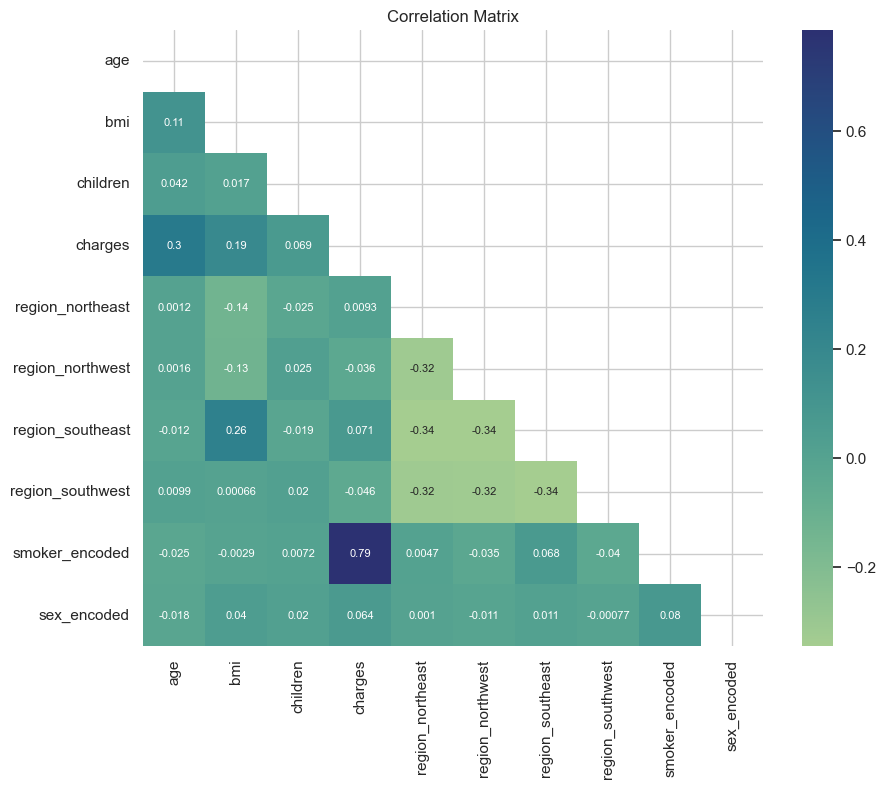

Relevant features based on correlation:
['age', 'smoker_encoded']


In [63]:
# <>
numr_cols = [x for x in df_encoded.columns if x not in ['age_group', 'bmi_group']]
corr_matrix_1 = df_encoded[numr_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_1, annot=True, cmap = 'crest',
                mask=np.triu(corr_matrix_1),#only display the upper triangle of the correlation matrix)
                            annot_kws = {"size":8});#adjust the font size

plt.title("Correlation Matrix")
plt.show()

# Identify relevant features based on correlation
threshold = 0.3
relevant_features = corr_matrix_1[(corr_matrix_1['charges'].abs() > threshold) & (corr_matrix_1.index != 'charges')].index.tolist()
print("Relevant features based on correlation:")
print(relevant_features)
save_fig('61_heatmap-correlation-encoded')


 (April 8) :Hypothesis Testing Chi-square Test of Independence¶ Test the hypothesis that the charges of the customers is independent of their gender.

Define Hypothesis

H₀: The two variables are independent & there's no relationship between them.
H₁: The two variables are dependent & there is a relationship between them.

In [64]:
# <>
df_cleaned_1 = df_cleaned.copy()
percetage_data(df_cleaned_1,['age_group','smoker'], sort=False)

count  percentage
age_group   smoker                   
Young       no        238       17.92
            yes        64        4.82
Adult       no        311       23.42
            yes        83        6.25
Middle-aged no        439       33.06
            yes       102        7.68
Senior      no         69        5.20
            yes        22        1.66

In [65]:
#<; April 8>:
df_cleaned_1=df_cleaned.copy()
bins_charg = [1000, 5000, 10000, 20000, 30000, 40000, 50000, 60000, 70000]
labels_charg = ['1k-5k', '5k-10k', '10k-20k', '20k-30k', '30k-40k', '40k-50k', '50k-60k', '60k-70k']

df_cleaned_1['charges_group'] = pd.cut(df_cleaned_1.charges, bins_charg, labels=labels_charg, include_lowest=True)
df_cleaned_1.head()

,age,sex,bmi,children,smoker,region,charges,bmi_group,age_group,charges_group
0,19,female,27.900,0,yes,southwest,16884.92400,overweight,Young,10k-20k
1,18,male,33.770,1,no,southeast,1725.55230,obese,Young,1k-5k
2,28,male,33.000,3,no,southeast,4449.46200,obese,Adult,1k-5k
3,33,male,22.705,0,no,northwest,21984.47061,normal,Adult,20k-30k
4,32,male,28.880,0,no,northwest,3866.85520,overweight,Adult,1k-5k


In [66]:
#<; April 8>:
df_cleaned_1.pivot_table(index='sex', columns='smoker', values='charges')

smoker,no,yes
sex,,
female,8761.069043,30249.563122
male,8114.735047,32969.478176


In [67]:
#<; April 8>:
df_cleaned_1.pivot_table(index='sex', columns='children', values='charges')

children,0,1,2,3,4,5
sex,,,,,,
female,11725.628464,12161.360414,13704.874577,13865.605066,13937.674562,9854.006419
male,12918.915668,13201.434841,16187.095325,16789.167419,13782.284829,7931.658310


In [68]:
#<; April 8>:
df_cleaned_1.pivot_table(index='sex', columns='region', values='charges')

region,northeast,northwest,southeast,southwest
sex,,,,
female,12975.204888,12479.870397,13210.756836,11058.019340
male,13854.005374,12421.085553,15977.762699,13412.883576


In [69]:
#<; April 8>:
# Create a contingency table
contingency_table = pd.crosstab(df_cleaned_1['sex'], df_cleaned_1['charges_group'])
contingency_table

charges_group,1k-5k,5k-10k,10k-20k,20k-30k,30k-40k,40k-50k,50k-60k,60k-70k
sex,,,,,,,,
female,173,181,192,56,27,28,2,0
male,183,169,160,55,56,42,2,2


Chi-square Test of Independence¶ Test the hypothesis that the charges of the customers is independent of their gender.

Define Hypothesis

H₀: The two variables are independent & there's no relationship between them.
H₁: The two variables are dependent & there is a relationship between them.

In [70]:
#<; April 8>:
chi2, p_value, dof, expected = chi2_contingency(contingency_table, correction=False)

# print('Expected frequencies:\n ', np.round(expected, 2))
print(f'Degrees of freedom: {dof}')
print(f'test stat: {chi2:.4f}')
print(f'p value: {p_value:.4f}')
print()

if p_value > 0.05:
    print('Fail to reject the null hypothesis.')
else:
    print('Reject the null hypothesis.')

Degrees of freedom: 7
test stat: 18.4687
p value: 0.0100

Reject the null hypothesis.


: At this significance level, it can be concluded that the two variables are dependent & there is a relationship between them.

# SECTION 2.2: Regression Model

In [71]:
# <>
df_encoded = pd.get_dummies(df_cleaned, columns=['region'], prefix='region', dtype=int)
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest
734,29,male,35.500,2,yes,44585.45587,obese,Adult,0,0,0,1
79,41,female,32.965,0,no,6571.02435,obese,Middle-aged,0,1,0,0
464,56,female,33.820,2,no,12643.37780,obese,Middle-aged,0,1,0,0
1160,37,female,34.105,1,no,6112.35295,obese,Adult,0,1,0,0
953,19,female,39.615,1,no,2730.10785,obese,Young,0,1,0,0


In [72]:
# <>
label_encoder = LabelEncoder()
df_encoded['smoker_encoded'] = label_encoder.fit_transform(df_encoded['smoker'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
658,18,male,33.66,0,no,1136.3994,obese,Young,0,0,1,0,0
1131,50,male,37.07,1,no,9048.0273,obese,Middle-aged,0,0,1,0,0
292,25,male,26.80,3,no,3906.1270,overweight,Young,0,0,0,1,0
1094,58,male,36.08,0,no,11363.2832,obese,Middle-aged,0,0,1,0,0
1101,54,female,32.30,1,no,11512.4050,obese,Middle-aged,1,0,0,0,0


In [73]:
# <>
df_encoded['sex_encoded'] = label_encoder.fit_transform(df_encoded['sex'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
1027,61,male,38.38,0,no,12950.0712,obese,Senior,0,1,0,0,0,1
638,23,female,34.96,3,no,4466.6214,obese,Young,0,1,0,0,0,0
134,22,female,28.05,0,no,2155.6815,overweight,Young,0,0,1,0,0,0
558,27,male,30.50,0,no,2494.0220,obese,Adult,0,0,0,1,0,1
1158,29,female,24.60,2,no,4529.4770,normal,Adult,0,0,0,1,0,0


In [74]:
# <>
df_encoded = df_encoded[[x for x in df_encoded.columns if x not in ['smoker', 'sex']]]
df_encoded.sample(5)

,age,bmi,children,charges,bmi_group,age_group,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
1246,42,37.90,0,6474.01300,obese,Middle-aged,0,0,0,1,0,0
492,20,27.93,0,1967.02270,overweight,Young,1,0,0,0,0,1
440,59,36.52,1,28287.89766,obese,Middle-aged,0,0,1,0,0,0
1265,26,27.06,0,17043.34140,overweight,Adult,0,0,1,0,1,1
7,37,27.74,3,7281.50560,overweight,Adult,0,1,0,0,0,0


: relationships between the features and the target variable charges. This will include examining correlations and creating scatter plots for continuous variables and box plots for categorical variables against charges

: Only age and smoking turned out to be relevant feature based on correlation analysis

In [75]:
#<> Scatter plot with regression line to fit BMI and smoking with charges
_g = sns.lmplot(x="bmi", y="charges", hue="smoker", data=df)
save_grid(_g, '62_lmplot-bmi-charges-by-smoker')


# SECTION 2.3: Linear and OLS Regression

In [76]:
# <; April 8>:Splitting the dataset into training and testing sets

XX = df_encoded[['age', 'sex_encoded', 'bmi', 'children', 'smoker_encoded', 'region_northeast',	'region_northwest',	'region_southeast',	'region_southwest']]# Features
yy = df_encoded['charges']# Target variable

XX_train, XX_test, yy_train, yy_test = train_test_split(XX, yy, test_size=0.2, random_state=42)

# Building the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(XX_train, yy_train)

# Predicting charges for the test set
yy_pred = linear_model.predict(XX_test)

# Calculating performance metrics
mse = mean_squared_error(yy_test, yy_pred)
r2 = r2_score(yy_test, yy_pred)

(mse, r2)

(35465549.24040005, 0.7448498340547971)

In [77]:
# <; April 8>:
# Retrieving the coefficients of the linear regression model
coefficients = pd.DataFrame(linear_model.coef_, XX.columns, columns=['Coefficient'])

# Displaying the coefficients to interpret the impact of each feature
coefficients.sort_values(by='Coefficient', ascending=False)

,Coefficient
smoker_encoded,23743.305766
region_northeast,856.698147
children,529.464610
bmi,349.241387
region_northwest,282.020100
age,259.030180
sex_encoded,-38.688059
region_southeast,-445.911307
region_southwest,-692.806941


 April 8:

Smoker Status:Strong positive effect (+23077). Smoker status significantly increases medical charges.

Age: Positive effect (+248). In another word, Older individuals tend to have higher medical charges.

Children: Having more children is associated with slightly higher charges.

BMI: Higher BMI is associated with higher medical charges.

Region:

region_north: Living in the north region is associated with slightly higher charges.

region_south: Living in the south region is associated with slightly lower charges and decreases charges slightly.

Sex:

sex:is associated with slightly lower charges.

Key Takeaways:

Smoking status is the most influential factor in determining medical charges.

Geographical region and gender have smaller impacts.

In [78]:
# <; April 8>:
X = df_encoded[['age', 'sex_encoded', 'bmi', 'children', 'smoker_encoded']]
y = df_encoded['charges']

# Add a constant to the independent variables matrix
X = sm.add_constant(X)

# This will create an instance of Linear Regression
est = sm.OLS(y, X).fit()

# Check the results
print(est.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     787.2
Date:                Sun, 13 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:09:12   Log-Likelihood:                -13440.
No. Observations:                1328   AIC:                         2.689e+04
Df Residuals:                    1322   BIC:                         2.692e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -1.21e+04    964.609    -12.

: Now that we have our regression results, we can use the params function to find the values of our slopes and intercept.

In [79]:
# <; April 8>:
print('Parameters: ', est.params)
print()
print('R2: ', round(est.rsquared, 3))
print()
print('Standard errors: ', est.bse)

Parameters:  const            -12095.798145
age                 256.983299
sex_encoded         -35.193643
bmi                 324.639234
children            476.386936
smoker_encoded    23618.034063
dtype: float64

R2:  0.749

Standard errors:  const             964.609361
age                11.877707
sex_encoded       332.281726
bmi                28.152221
children          137.132593
smoker_encoded    411.852918
dtype: float64


In [80]:
# <; April 8>:
prediction = est.predict()

<Figure size 640x480 with 0 Axes>

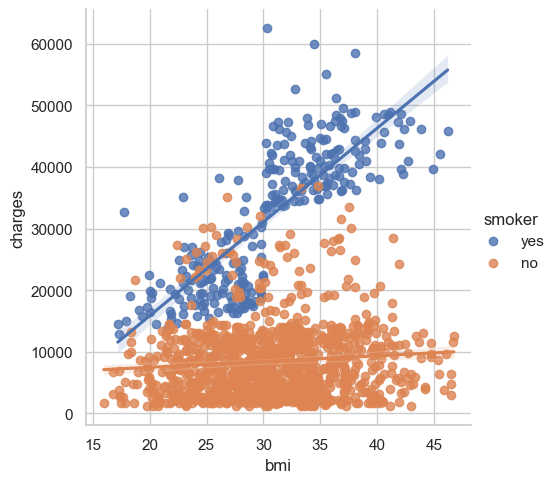

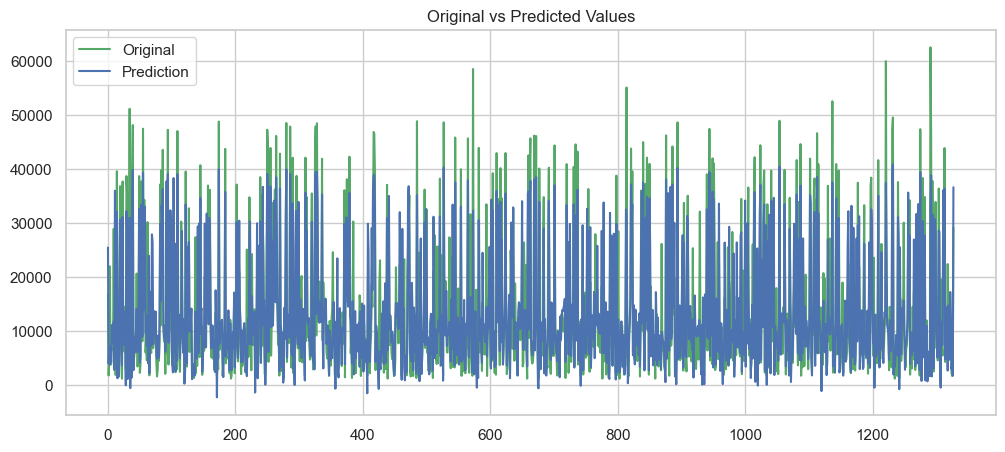

In [81]:
# <; April 8>:
plt.figure(figsize=(12, 5))

plt.plot(df_encoded['charges'], color='g', label='Original')
plt.plot(prediction, color='b', label='Prediction')

plt.title('Original vs Predicted Values')
plt.legend()
save_fig('63_ols-original-vs-predicted')
plt.show()

In [82]:
# <; April 8>:
residuals = pd.Series(est.resid)
residuals[:5]

0    -8577.429244
1    -2208.609180
2    -2757.334135
3    18264.079704
4    -1601.199679
dtype: float64

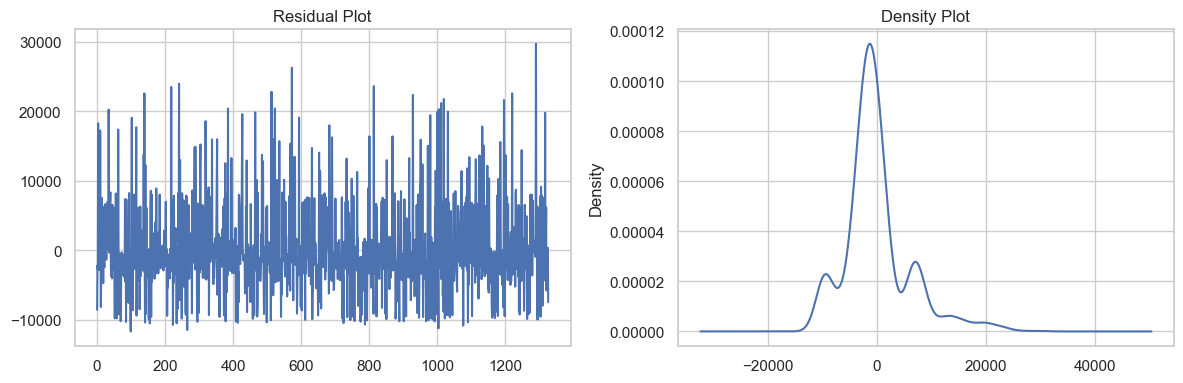

In [83]:
# <; April 8>:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

residuals.plot(ax=ax[0])
residuals.plot(kind='density', ax=ax[1])

ax[0].set_title('Residual Plot')
ax[1].set_title('Density Plot')

plt.tight_layout()
save_fig('64_ols-residuals-density')
plt.show()

 April 8: In this model, R-squared is 0.750, indicating that approximately 75% of the variance in charges can be explained by age and smoker_encoded. Additionally, The adjusted R-squared here is 0.749, which is very close to the R-squared value, indicating that the additional predictor (smoker_encoded) contributes meaningfully to the model.

Overall, the regression model suggests that both age and smoking status (encoded as smoker_encoded) are significant predictors of charges, with smokers having substantially higher charges compared to non-smokers, even after controlling for age. Additionally, the model's diagnostics indicate potential issues with non-normality and skewness in the residuals distribution, which might warrant further investigation or model refinement.

# SECTION 3: Linear Regression and Decision Tree

In [84]:
# <; April 8>: Select the relevant features
X = df_encoded[['age', 'bmi', 'smoker_encoded']]
y = df_encoded['charges']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [85]:
# <; April 8>:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

In [86]:
# <; April 8>:
lm.fit(X_train,y_train)

LinearRegression()

In [87]:
# <; April 8>:
print('Intercept', lm.intercept_)
print('Coefficient', lm.coef_)
print('Score', lm.score(X_test, y_test))

Intercept -12009.42599594116
Coefficient [  262.06710911   328.98624301 23765.27695741]
Score 0.7488004023499725


In [88]:
# <; April 8>:
y_pred1 = lm.predict(X_test)

C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\2853423267.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax1 = sns.distplot(y_test, hist=False, color="g", label="Actual Value")
C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\2853423267.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.dist

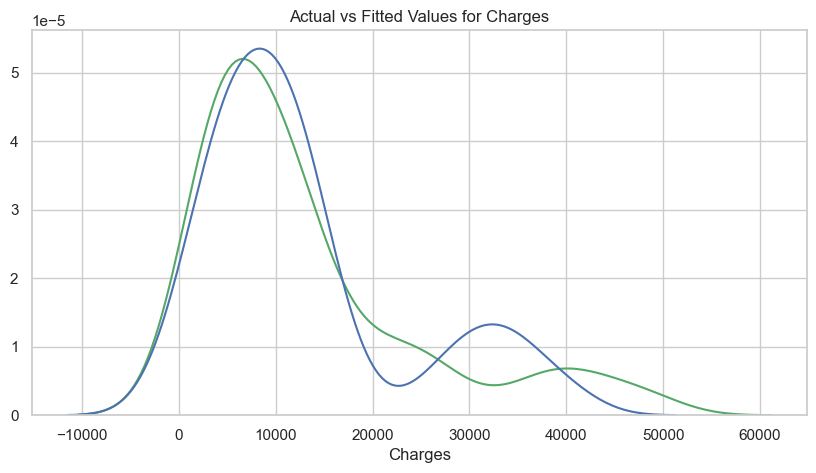

In [89]:
# <; April 8>:
plt.figure(figsize=(10, 5))
ax1 = sns.distplot(y_test, hist=False, color="g", label="Actual Value")
sns.distplot(y_pred1, hist=False, color="b", label="Fitted Values" , ax=ax1)
plt.title('Actual vs Fitted Values for Charges')
plt.xlabel('Charges')
plt.ylabel('')
save_fig('65_ols-actual-vs-fitted-kde')
plt.show()
plt.close()

C:\Users\meddi\AppData\Local\Temp\ipykernel_8088\335174671.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(y_test, dt_predictions, cmap = 'crest', label='Decision Tree')


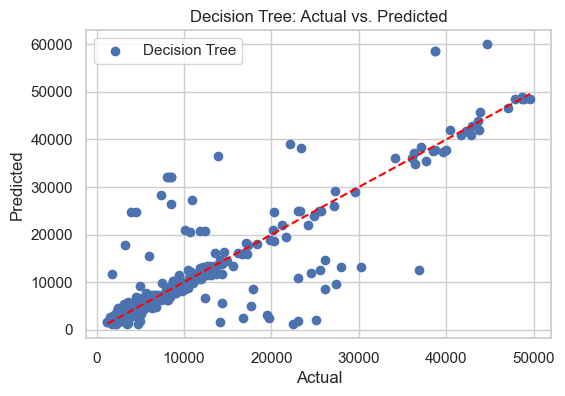

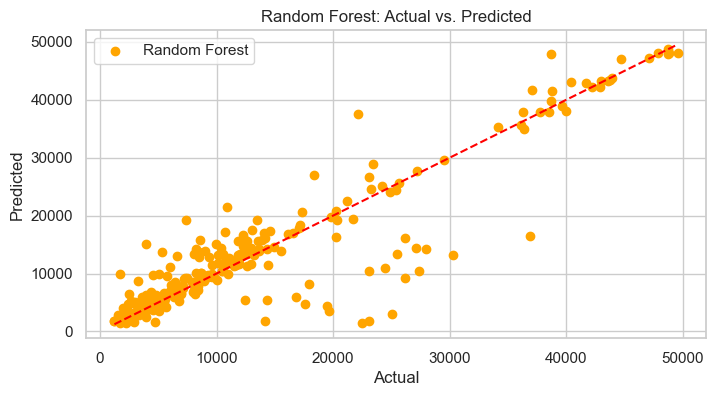

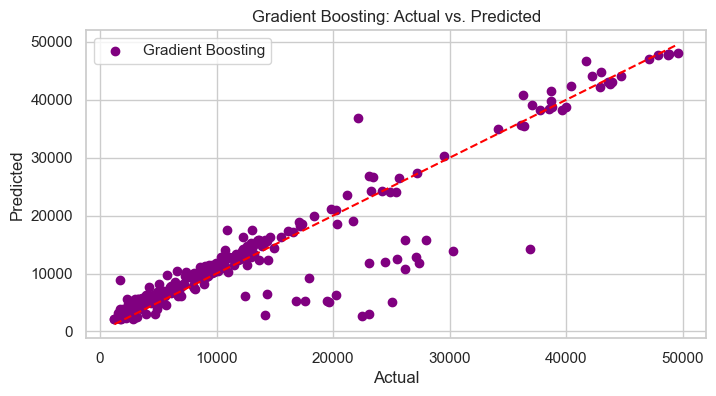

In [90]:
# <; April 8>:
#Decision Tree
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_mae = mean_absolute_error(y_test, dt_predictions)

# Plot actual vs. predicted values for Decision Tree
plt.figure(figsize=(6, 4))
plt.scatter(y_test, dt_predictions, cmap = 'crest', label='Decision Tree')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Decision Tree: Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
save_fig('66_decision-tree-actual-vs-predicted')
plt.show()


# Random Forest
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)

# Plot actual vs. predicted values for Random Forest
plt.figure(figsize=(8, 4))
plt.scatter(y_test, rf_predictions, color='orange', label='Random Forest')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Random Forest: Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
save_fig('67_random-forest-actual-vs-predicted')
plt.show()

# Gradient Boosting
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)
gb_mse = mean_squared_error(y_test, gb_predictions)
gb_mae = mean_absolute_error(y_test, gb_predictions)

# Plot actual vs. predicted values for Gradient Boosting
plt.figure(figsize=(8, 4))
plt.scatter(y_test, gb_predictions, color='purple', label='Gradient Boosting')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Gradient Boosting: Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
save_fig('68_gradient-boosting-actual-vs-predicted')
plt.show()


In [91]:
# <; April 8>: Print the evaluation metrics
print("Decision Tree - MSE: ", dt_mse)
print("Decision Tree - MAE: ", dt_mae)

print("Random Forest - MSE: ", rf_mse)
print("Random Forest - MAE: ", rf_mae)
print("Gradient Boosting - MSE: ", gb_mse)
print("Gradient Boosting - MAE: ", gb_mae)

Decision Tree - MSE:  46278717.093904234
Decision Tree - MAE:  3338.7520644924807
Random Forest - MSE:  24783035.356655106
Random Forest - MAE:  2672.096183306904
Gradient Boosting - MSE:  20658768.173987444
Gradient Boosting - MAE:  2453.3131772817314


In [92]:
# <; April 8>:
print("Decision Tree:")

# Feature importances
importance = dt_model.feature_importances_

for i, feature in enumerate(X.columns):
    print(f"{feature}: {importance[i]}")

print()


# Random Forest
print("Random Forest:")

# Feature importances
importance = rf_model.feature_importances_

for i, feature in enumerate(X.columns):
    print(f"{feature}: {importance[i]}")

print()

# Gradient Boosting
print("Gradient Boosting:")

# Feature importances
importance = gb_model.feature_importances_
for i, feature in enumerate(X.columns):
    print(f"{feature}: {importance[i]}")

Decision Tree:
age: 0.1350743172253909
bmi: 0.24584631799924364
smoker_encoded: 0.6190793647753655

Random Forest:
age: 0.1347597062718943
bmi: 0.24652510932502977
smoker_encoded: 0.6187151844030759

Gradient Boosting:
age: 0.12015414835851428
bmi: 0.19169753698430309
smoker_encoded: 0.6881483146571826


In [93]:
# <; April 8>:
# Example input for prediction
new_data = pd.DataFrame({'age': [30], 'bmi': [32.10], 'smoker_encoded': [1]})

# Decision Tree
dt_predictions = dt_model.predict(new_data)
print("Decision Tree Predictions:", dt_predictions)

# Random Forest
rf_predictions = rf_model.predict(new_data)
print("Random Forest Predictions:", rf_predictions)

# Gradient Boosting
gb_predictions = gb_model.predict(new_data)
print("Gradient Boosting Predictions:", gb_predictions)

Decision Tree Predictions: [36837.467]
Random Forest Predictions: [35847.0237633]
Gradient Boosting Predictions: [38087.36740713]


 April 8:The most influential factors affecting medical insurance charges are whether the person is a smoker, their BMI (Body Mass Index), and their age.

Smoking Impact: Smokers tend to have significantly higher medical insurance charges compared to non-smokers. This is a crucial insight that highlights the importance of lifestyle choices on healthcare costs.

Age and Charges: The age of an individual is positively correlated with insurance charges. Older individuals tend to have higher medical costs, which is understandable given the increased likelihood of health issues as age advances.

BMI Influence: Higher BMI values are associated with increased medical insurance charges. This suggests that maintaining a healthy weight can positively impact healthcare costs.

Suggestions Promote Healthy Lifestyles: Encourage smoking cessation programs and awareness campaigns to reduce the number of smokers. This could lead to substantial savings in healthcare costs.

Health Awareness: Run campaigns to educate people about the impact of BMI on health and insurance costs. Promoting healthy eating and exercise can help individuals maintain a healthy weight and potentially lower their medical expenses.

Model Refinement: Continue refining and optimizing predictive models. This could involve exploring more advanced algorithms or techniques to improve the accuracy of predictions.

Regular Data Updates: Regularly update the dataset with new data to ensure that the models remain relevant and accurate. Healthcare trends and cost patterns may change over time.

Personalized Recommendations: Provide personalized recommendations to individuals based on their age, smoking status, and BMI to help them make informed decisions about their healthcare and insurance choices.

By implementing these insights and suggestions, the insurance industry can make informed decisions to optimize insurance plans and promote healthier lifestyles among their customers.

# GLM Regression (Not included in report)

In [94]:
# <; April 8>:
model = sm.formula.glm(
    formula='charges ~ age + sex_encoded + smoker_encoded + bmi +children',
    data=df_encoded).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                 1328
Model:                            GLM   Df Residuals:                     1322
Model Family:                Gaussian   Df Model:                            5
Link Function:               Identity   Scale:                      3.6329e+07
Method:                          IRLS   Log-Likelihood:                -13440.
Date:                Sun, 13 Sep 2026   Deviance:                   4.8027e+10
Time:                        11:09:15   Pearson chi2:                 4.80e+10
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9484
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       -1.21e+04    964.609    -12.

In [95]:
# <; April 8>:
print('Parameters: ', model.params)
print()
print('Standard errors: ', model.bse)

Parameters:  Intercept        -12095.798145
age                 256.983299
sex_encoded         -35.193643
smoker_encoded    23618.034063
bmi                 324.639234
children            476.386936
dtype: float64

Standard errors:  Intercept         964.609361
age                11.877707
sex_encoded       332.281726
smoker_encoded    411.852918
bmi                28.152221
children          137.132593
dtype: float64


In [96]:
# <; April 8>:
prediction_1= model.predict()

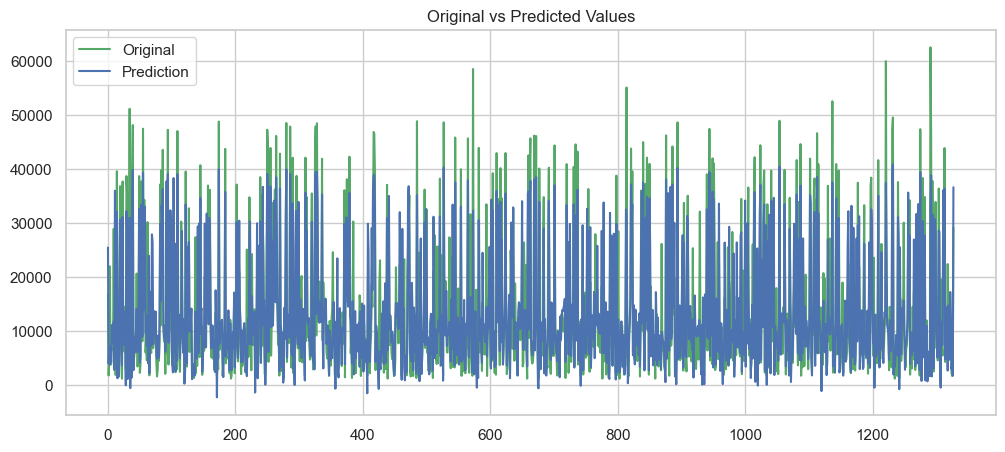

In [97]:
# <; April 8>:
plt.figure(figsize=(12, 5))

plt.plot(df_encoded['charges'], color='g', label='Original')
plt.plot(prediction_1, color='b', label='Prediction')

plt.title('Original vs Predicted Values')
plt.legend()
save_fig('69_final-model-original-vs-predicted')
plt.show()

In [98]:
# <; April 8>:
residuals_1 = pd.Series(model.resid_pearson)
residuals_1[:5]

0    -8577.429244
1    -2208.609180
2    -2757.334135
3    18264.079704
4    -1601.199679
dtype: float64

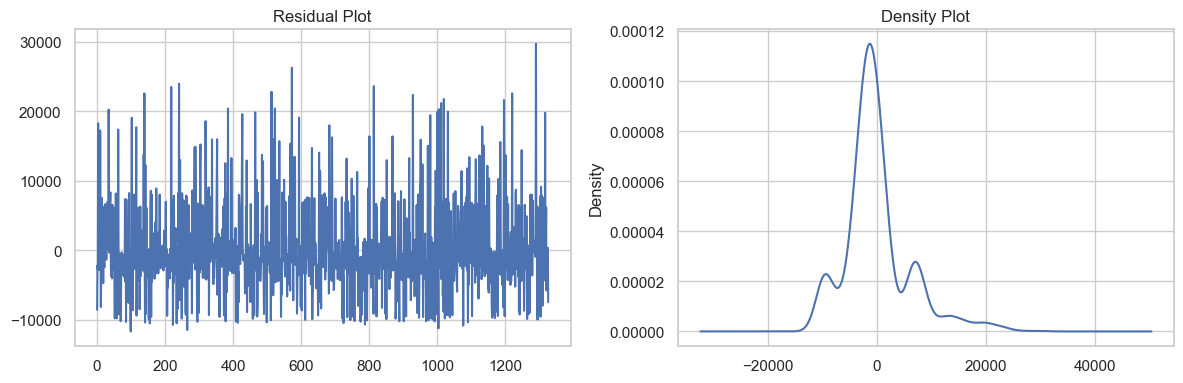

In [99]:
# <; April 8>:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

residuals_1.plot(ax=ax[0])
residuals_1.plot(kind='density', ax=ax[1])

ax[0].set_title('Residual Plot')
ax[1].set_title('Density Plot')

plt.tight_layout()
save_fig('70_final-model-residuals-density')
plt.show()

:

The residual plot the model is not consistently overestimating or underestimating the actual values. However, it's difficult to say definitively from this plot alone whether the residuals are normally distributed, as there are not many data points and the vertical axis scale is very small.

The density plot appears to be roughly symmetrical around zero, which is consistent with the idea that the residuals are centered around zero. However, the shape of the distribution is difficult to determine precisely due to the limited number of data points. It's possible that the true distribution may not be perfectly normal, even though it appears somewhat symmetrical in this plot.